# Imports and Configuration

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import numpy as np
import cv2 
import pywt # For Wavelet Transform
import timm # For the ViT backbone
import matplotlib.pyplot as plt

# Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Hyperparameters aligned with Battocchio et al. and Corvi et al.
NUM_FRAMES = 8       # Temporal batch size
IMG_SIZE = 224       # Standard ViT input size
BATCH_SIZE = 16
LEARNING_RATE = 1e-4

Using device: cuda


# Wavelet Augmentation Function


In [4]:
def wavelet_blend(fake_frame, real_frame):
    """
    Applies Haar Wavelet decomposition and replaces the low-frequency 
    and H/V high-frequency components of 'fake_frame' with those from 'real_frame'.
    Keeps only the Diagonal details (cD) of the fake frame.
    """
    # Make sure tensors are on CPU and convert them to numpy
    # [C, H, W] -> [H, W, C]
    fake_np = fake_frame.detach().cpu().numpy().transpose(1, 2, 0) 
    real_np = real_frame.detach().cpu().numpy().transpose(1, 2, 0)
    
    aug_frame = np.zeros_like(fake_np)
    
    # Iterate over channels (RGB)
    for ch in range(3): 
        # 1-level decomposition (Haar)
        coeffs_fake = pywt.dwt2(fake_np[:,:,ch], 'haar')
        coeffs_real = pywt.dwt2(real_np[:,:,ch], 'haar')
        
        # cA = Approximation (Low frequencies)
        # cH = Horizontal details
        # cV = Vertical details
        # cD = Diagonal details (the ones we want to keep from the Fake!)
        cA_fake, (cH_fake, cV_fake, cD_fake) = coeffs_fake
        cA_real, (cH_real, cV_real, cD_real) = coeffs_real
        
        # MIXING STRATEGY:
        # Keep cD (Diagonal) from the FAKE (contains typical checkerboard artifacts)
        # Replace everything else with the REAL (removes semantic bias)
        new_coeffs = (cA_real, (cH_real, cV_real, cD_fake)) 
        
        # Reconstruction
        rec = pywt.idwt2(new_coeffs, 'haar')
        
        # Handle odd dimensions (idwt2 may be off by 1 pixel if input size is odd)
        # Coerce the shape to match the input
        h, w = fake_np.shape[:2]
        aug_frame[:,:,ch] = rec[:h, :w]
        
    # Safety clip: Bring values back to the [0, 1] range
    aug_frame = np.clip(aug_frame, 0.0, 1.0)
        
    # Return float32 tensor [C, H, W]
    return torch.from_numpy(aug_frame.transpose(2, 0, 1)).float()


In [5]:
# Forensic-Oriented Augmentation (from "Seeing What Matters")
import io
from PIL import Image

class ForensicAugmentation:
    """
    Implements the 5 forensic augmentations proposed in the paper
    to improve detector robustness against post-processing
    """
    def __init__(self):
        self.jpeg_qualities = [70, 75, 80, 85, 90, 95]
        self.blur_kernels = [(3,3), (5,5), (7,7)]
        self.noise_levels = [0.01, 0.02, 0.03, 0.05]
        self.resize_factors = [0.7, 0.8, 0.9, 1.1, 1.2]
        
    def jpeg_compression(self, frame):
        """Simulate JPEG compression with random quality"""
        quality = int(np.random.choice(self.jpeg_qualities))  
        # Convert tensor [C,H,W] to numpy [H,W,C]
        frame_np = (frame.cpu().numpy().transpose(1,2,0) * 255).astype(np.uint8)
        
        # Simulate JPEG encode/decode
        pil_img = Image.fromarray(frame_np)
        buffer = io.BytesIO()
        pil_img.save(buffer, format='JPEG', quality=quality)
        buffer.seek(0)
        compressed = Image.open(buffer)
        
        # Return as tensor
        result = np.array(compressed).astype(np.float32) / 255.0
        return torch.from_numpy(result.transpose(2,0,1)).float()
    
    def gaussian_blur(self, frame):
        """Apply Gaussian blur"""
        kernel = int(np.random.choice([3, 5, 7])) 
        frame_np = frame.cpu().numpy().transpose(1,2,0)
        blurred = cv2.GaussianBlur(frame_np, (kernel, kernel), 0)
        return torch.from_numpy(blurred.transpose(2,0,1)).float()
    
    def gaussian_noise(self, frame):
        """Add Gaussian noise"""
        noise_level = float(np.random.choice(self.noise_levels)) 
        noise = torch.randn_like(frame) * noise_level
        return torch.clamp(frame + noise, 0, 1)
    
    def resize_artifact(self, frame):
        """Simulate resizing with quality loss"""
        factor = float(np.random.choice(self.resize_factors)) 
        h, w = frame.shape[1], frame.shape[2]
        new_h, new_w = int(h * factor), int(w * factor)
        
        frame_np = frame.cpu().numpy().transpose(1,2,0)
        resized = cv2.resize(frame_np, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
        restored = cv2.resize(resized, (w, h), interpolation=cv2.INTER_LINEAR)
        
        return torch.from_numpy(restored.transpose(2,0,1)).float()
    
    def color_jitter(self, frame):
        """Alter brightness/contrast/saturation"""
        brightness = np.random.uniform(0.8, 1.2)
        contrast = np.random.uniform(0.8, 1.2)
        saturation = np.random.uniform(0.8, 1.2)
        
        frame_np = frame.cpu().numpy().transpose(1,2,0)
        
        # Brightness
        frame_np = np.clip(frame_np * brightness, 0, 1)
        
        # Contrast
        mean = frame_np.mean()
        frame_np = np.clip((frame_np - mean) * contrast + mean, 0, 1)
        
        # Saturation (convert to HSV)
        hsv = cv2.cvtColor((frame_np * 255).astype(np.uint8), cv2.COLOR_RGB2HSV).astype(np.float32)
        hsv[:,:,1] = np.clip(hsv[:,:,1] * saturation, 0, 255)
        rgb = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB).astype(np.float32) / 255.0
        
        return torch.from_numpy(rgb.transpose(2,0,1)).float()
    
    def apply_random_mix(self, frame, num_augs=2):
        """
        Apply 2-3 random augmentations in sequence
        This is the mixing strategy proposed in the paper
        """
        augs = [
            self.jpeg_compression,
            self.gaussian_blur,
            self.gaussian_noise,
            self.resize_artifact,
            self.color_jitter
        ]
        
        num_to_apply = int(np.random.randint(1, num_augs + 1))
        selected = np.random.choice(len(augs), num_to_apply, replace=False)
        
        for idx in selected:
            frame = augs[int(idx)](frame) 
        
        return frame

# Initialize the object globally
forensic_aug = ForensicAugmentation()

def pyramid_noise_augmentation(frame, noise_levels=[0.01, 0.03, 0.05]):
    """
    Pyramid Noise Injection (from Battocchio et al.)
    Applies Gaussian noise with varying levels to simulate generative artifacts
    """
    noise_level = float(np.random.choice(noise_levels))
    noise = torch.randn_like(frame) * noise_level
    return torch.clamp(frame + noise, 0, 1)

# Configurator Manager

In [6]:
class ExperimentConfig:
    """Manages experiment configurations"""
    
    @staticmethod
    def get_baseline_simple():
        """Simple baseline: Base ViT without advanced augmentations"""
        return {
            'name': 'Baseline_Simple_ViT',
            'model_name': 'vit_base_patch16_224',
            'use_advanced_features': False,
            'augmentations': {
                'wavelet': False,
                'forensic': False,
                'pyramid_noise': False,
                'multi_scale_temporal': False
            },
            'loss': {
                'temporal_consistency': False,
                'frequency_domain': False
            }
        }
    
    @staticmethod
    def get_baseline_dinov2():
        """DinoV2 baseline (State-of-the-Art from papers)"""
        return {
            'name': 'Baseline_DinoV2',
            'model_name': 'vit_base_patch14_dinov2.lvd142m',
            'use_advanced_features': False,
            'augmentations': {
                'wavelet': False,
                'forensic': False,
                'pyramid_noise': False,
                'multi_scale_temporal': False
            },
            'loss': {
                'temporal_consistency': False,
                'frequency_domain': False
            }
        }
    
    @staticmethod
    def get_full_model():
        """Your model with ALL improvements"""
        return {
            'name': 'Proposed_Full_Model',
            'model_name': 'vit_base_patch16_224',
            'use_advanced_features': True,
            'augmentations': {
                'wavelet': True,
                'forensic': True,
                'pyramid_noise': True,
                'multi_scale_temporal': True
            },
            'loss': {
                'temporal_consistency': True,
                'frequency_domain': True
            }
        }
    
    @staticmethod
    def get_ablation_configs():
        """Generates all configurations for ablation study"""
        full = ExperimentConfig.get_full_model()
        
        ablations = {
            'Full_Model': full,
            'w/o_Wavelet': {**full, 'augmentations': {**full['augmentations'], 'wavelet': False}},
            'w/o_Forensic': {**full, 'augmentations': {**full['augmentations'], 'forensic': False}},
            'w/o_Pyramid_Noise': {**full, 'augmentations': {**full['augmentations'], 'pyramid_noise': False}},
            'w/o_Multi_Scale': {**full, 'augmentations': {**full['augmentations'], 'multi_scale_temporal': False}},
            'w/o_Spatial_Attn': {**full, 'use_advanced_features': False},
            'w/o_Temp_Consistency': {**full, 'loss': {**full['loss'], 'temporal_consistency': False}},
            'w/o_Freq_Loss': {**full, 'loss': {**full['loss'], 'frequency_domain': False}}
        }
        
        return ablations

# Print all configurations
print("=" * 70)
print("EXPERIMENT CONFIGURATIONS")
print("=" * 70)

configs = {
    'Baseline Simple': ExperimentConfig.get_baseline_simple(),
    'Baseline DinoV2': ExperimentConfig.get_baseline_dinov2(),
    'Full Model': ExperimentConfig.get_full_model()
}

for name, cfg in configs.items():
    print(f"\n{name}:")
    print(f"  Model: {cfg['model_name']}")
    print(f"  Advanced Features: {cfg['use_advanced_features']}")
    print(f"  Augmentations: {cfg['augmentations']}")
    print(f"  Loss Components: {cfg['loss']}")


EXPERIMENT CONFIGURATIONS

Baseline Simple:
  Model: vit_base_patch16_224
  Advanced Features: False
  Augmentations: {'wavelet': False, 'forensic': False, 'pyramid_noise': False, 'multi_scale_temporal': False}
  Loss Components: {'temporal_consistency': False, 'frequency_domain': False}

Baseline DinoV2:
  Model: vit_base_patch14_dinov2.lvd142m
  Advanced Features: False
  Augmentations: {'wavelet': False, 'forensic': False, 'pyramid_noise': False, 'multi_scale_temporal': False}
  Loss Components: {'temporal_consistency': False, 'frequency_domain': False}

Full Model:
  Model: vit_base_patch16_224
  Advanced Features: True
  Augmentations: {'wavelet': True, 'forensic': True, 'pyramid_noise': True, 'multi_scale_temporal': True}
  Loss Components: {'temporal_consistency': True, 'frequency_domain': True}


# Custom Dataset Class

In [7]:
class FakeVideoDataset(Dataset):
    def __init__(self, video_paths, labels, real_video_paths=None, transform=None, 
                 num_frames=8, is_train=True, config=None):
        """
        Args:
            config: ExperimentConfig dict per abilitare/disabilitare augmentations
        """
        self.video_paths = video_paths
        self.labels = labels
        self.real_video_paths = real_video_paths if real_video_paths is not None else []
        self.transform = transform
        self.num_frames = num_frames
        self.is_train = is_train
        
        if config is None:
            config = ExperimentConfig.get_full_model()
        self.config = config
        
        model_name = config.get('model_name', 'vit_base_patch16_224')
        if 'dinov2' in model_name.lower() or '518' in model_name:
            self.img_size = 518
        elif '384' in model_name:
            self.img_size = 384
        else:
            self.img_size = 224
        
        print(f"Dataset using image size: {self.img_size}x{self.img_size} for model {model_name}")
        
        self.temporal_configs = [
            {'num_frames': 4, 'name': 'sparse'},
            {'num_frames': 8, 'name': 'uniform'},
            {'num_frames': 16, 'name': 'dense'}
        ]

    def load_video_frames(self, path, num_frames=None):
        """Loads frames with adaptive resizing based on model"""
        if num_frames is None:
            num_frames = self.num_frames
            
        cap = cv2.VideoCapture(path)
        if not cap.isOpened():
            print(f"Warning: Could not open {path}")
            return torch.zeros(num_frames, 3, self.img_size, self.img_size)

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        if total_frames <= 0:
            cap.release()
            return torch.zeros(num_frames, 3, self.img_size, self.img_size)

        indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
        
        frames = []
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if not ret:
                frame = np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8) if not frames else frames[-1]
            else:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = cv2.resize(frame, (self.img_size, self.img_size))
            
            frames.append(frame)
        cap.release()

        buffer = np.stack(frames)
        video_tensor = torch.from_numpy(buffer).float().permute(0, 3, 1, 2) / 255.0
        
        return video_tensor

    def get_reference_real_video(self, num_frames):
        """Selects a random real video from the pool for augmentation"""
        if not self.real_video_paths:
            return None
        rand_idx = np.random.randint(0, len(self.real_video_paths))
        return self.load_video_frames(self.real_video_paths[rand_idx], num_frames)

    def __getitem__(self, idx):
        path = self.video_paths[idx]
        label = self.labels[idx]
        
        # Multi-scale temporal
        if (self.is_train and 
            self.config['augmentations']['multi_scale_temporal'] and 
            np.random.rand() < 0.3):
            config = np.random.choice(self.temporal_configs)
            num_frames = config['num_frames']
        else:
            num_frames = self.num_frames
        
        video = self.load_video_frames(path, num_frames)
        
        # Padding/trimming
        if video.shape[0] != self.num_frames:
            if video.shape[0] < self.num_frames:
                padding = self.num_frames - video.shape[0]
                video = torch.cat([video, video[-1:].repeat(padding, 1, 1, 1)], dim=0)
            else:
                video = video[:self.num_frames]

        # AUGMENTATION PIPELINE 
        if self.is_train:
            aug_frames = []
            
            for i in range(self.num_frames):
                frame = video[i]
                
                # 1. Wavelet Augmentation 
                if (self.config['augmentations']['wavelet'] and 
                    label == 1 and 
                    len(self.real_video_paths) > 0 and 
                    np.random.rand() < 0.5):
                    ref_video = self.get_reference_real_video(self.num_frames)
                    if ref_video is not None:
                        frame = wavelet_blend(frame, ref_video[i])
                
                # 2. Forensic Augmentation
                if (self.config['augmentations']['forensic'] and 
                    np.random.rand() < 0.6):
                    frame = forensic_aug.apply_random_mix(frame, num_augs=2)
                
                # 3. Pyramid Noise 
                if (self.config['augmentations']['pyramid_noise'] and 
                    np.random.rand() < 0.3):
                    frame = pyramid_noise_augmentation(frame)
                
                aug_frames.append(frame)
            
            video = torch.stack(aug_frames)

        if self.transform:
            video = torch.stack([self.transform(f) for f in video])
            
        return video, label

    def __len__(self):
        return len(self.video_paths)

# Advanced Architecture Components

In [8]:
class SpatialAttention(nn.Module):
    """
    Spatial Attention Module (from Battocchio et al.)
    Allows the model to focus on the most informative regions
    """
    def __init__(self, dim=768, reduction=4):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(dim, dim // reduction),
            nn.ReLU(),
            nn.Linear(dim // reduction, dim),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        # x: [B, F, 768]
        weights = self.attention(x)
        return x * weights

class TemporalConsistency(nn.Module):
    """
    Temporal Consistency Checker
    Verifies temporal coherence between frames (fakes often show inconsistencies)
    """
    def __init__(self, input_dim=768, hidden_dim=256):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
    
    def forward(self, temporal_features):
        # temporal_features: [B, F, 768]
        lstm_out, (h_n, _) = self.lstm(temporal_features)
        # Use the last hidden state (bidirectional concatenation)
        consistency_score = self.fc(torch.cat([h_n[0], h_n[1]], dim=1))
        return consistency_score

def frequency_domain_loss(features1, features2):
    """
    FFT-based Loss (from "Seeing What Matters")
    Compares frequency spectra to capture imperceptible artifacts
    """
    # Reshape if necessary: [B, 768] -> [B, 1, 768]
    if len(features1.shape) == 2:
        features1 = features1.unsqueeze(1)
        features2 = features2.unsqueeze(1)
    
    fft1 = torch.fft.rfft(features1, dim=-1)
    fft2 = torch.fft.rfft(features2, dim=-1)
    
    # Compare spectral magnitudes
    mag1 = torch.abs(fft1)
    mag2 = torch.abs(fft2)
    
    return nn.functional.mse_loss(mag1, mag2)

# 3D-ViT Model Architecture


In [9]:
class Detector3DViT(nn.Module):
    def __init__(self, pretrained=True, use_advanced_features=True, model_name='vit_base_patch16_224'):
        super(Detector3DViT, self).__init__()
        
        self.use_advanced_features = use_advanced_features
        self.model_name = model_name
        
        # Load ViT backbone (supporta diversi modelli)
        print(f"Loading backbone: {model_name}")
        self.backbone = timm.create_model(model_name, pretrained=pretrained)
        
        # Determina la dimensione delle features in base al modello
        if 'dinov2' in model_name.lower():
            feature_dim = 768  # DinoV2 base ha 768 features
        elif 'vit_base' in model_name.lower():
            feature_dim = 768
        elif 'vit_large' in model_name.lower():
            feature_dim = 1024
        elif 'vit_small' in model_name.lower():
            feature_dim = 384
        else:
            feature_dim = 768  # Default
        
        self.feature_dim = feature_dim
        
        # Freeze backbone
        for param in self.backbone.parameters():
            param.requires_grad = False
        
        # Advanced modules (solo se abilitati)
        if use_advanced_features:
            self.spatial_attn = SpatialAttention(dim=feature_dim, reduction=4)
            self.temporal_checker = TemporalConsistency(input_dim=feature_dim, hidden_dim=256)
        
        # Classifier Head (Enhanced)
        self.head = nn.Sequential(
            nn.Linear(feature_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)  # Binary output
        )
        
    def forward(self, x, return_features=False):
        # Input: [B, F, C, H, W] -> [B, 8, 3, 224, 224]
        b, f, c, h, w = x.shape
        
        # Merge Batch and Frames
        x = x.view(b * f, c, h, w) 
        
        # Feature extraction
        features = self.backbone.forward_features(x)  # [B*F, Tokens, Dim]
        
        # CLS token extraction
        cls_token = features[:, 0]  # [B*F, feature_dim]
        
        # Restore temporal dimension
        cls_token = cls_token.view(b, f, -1)  # [B, F, feature_dim]
        
        # Apply Spatial Attention
        if self.use_advanced_features:
            cls_token = self.spatial_attn(cls_token)
        
        # Temporal Pooling (mean across frames)
        video_features = torch.mean(cls_token, dim=1)  # [B, feature_dim]
        
        # Final classification
        logits = self.head(video_features)
        
        # Also compute temporal consistency
        if self.use_advanced_features and self.training:
            temp_consistency = self.temporal_checker(cls_token)
            if return_features:
                return logits, temp_consistency, video_features
            return logits, temp_consistency
        
        if return_features:
            return logits, video_features
        return logits

# Training Setup and Loop


In [21]:
def train_one_epoch(model, loader, criterion, optimizer, config):
    """Training with configurable loss components"""
    model.train()
    total_loss = 0.0
    total_cls_loss = 0.0
    total_temp_loss = 0.0
    total_freq_loss = 0.0
    correct = 0
    total = 0
    
    use_temp_loss = config['loss']['temporal_consistency']
    use_freq_loss = config['loss']['frequency_domain']
    
    for i, (videos, labels) in enumerate(loader):
        videos = videos.to(device)
        labels = labels.to(device).float().unsqueeze(1)
        
        optimizer.zero_grad()
        
        # Forward pass
        if config['use_advanced_features'] and (use_temp_loss or use_freq_loss):
            outputs, temp_consistency, features = model(videos, return_features=True)
            
            # Loss 1: Classification (always present)
            cls_loss = criterion(outputs, labels)
            loss = cls_loss
            total_cls_loss += cls_loss.item()
            
            # Loss 2: Temporal Consistency (optional)
            temp_loss = torch.tensor(0.0).to(device)
            if use_temp_loss:
                temp_loss = nn.functional.mse_loss(temp_consistency, labels) * 0.3
                loss = loss + temp_loss
                total_temp_loss += temp_loss.item()
            
            # Loss 3: Frequency Domain (optional)
            freq_loss = torch.tensor(0.0).to(device)
            if use_freq_loss:
                real_mask = (labels == 0).squeeze()
                if real_mask.sum() > 0:
                    real_features_mean = features[real_mask].mean(dim=0, keepdim=True)
                    freq_loss = frequency_domain_loss(
                        features, real_features_mean.expand_as(features)
                    ) * 0.1
                    loss = loss + freq_loss
                    total_freq_loss += freq_loss.item()
        else:
            # Simple forward for baseline models
            # FIX: Handle both single output and tuple output
            model_output = model(videos)
            
            # Extract logits (handle tuple from models with use_advanced_features=True)
            if isinstance(model_output, tuple):
                outputs = model_output[0]  # Take only logits
            else:
                outputs = model_output
                
            cls_loss = criterion(outputs, labels)
            loss = cls_loss
            total_cls_loss += cls_loss.item()
            temp_loss = torch.tensor(0.0).to(device)
            freq_loss = torch.tensor(0.0).to(device)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        preds = torch.sigmoid(outputs) > 0.5
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        if i % 10 == 0:
            # Build loss string based on active components
            loss_str = f"Cls: {cls_loss.item():.3f}"
            if use_temp_loss and temp_loss.item() > 0:
                loss_str += f", Temp: {temp_loss.item():.3f}"
            if use_freq_loss and freq_loss.item() > 0:
                loss_str += f", Freq: {freq_loss.item():.4f}"
            print(f"   Step {i}/{len(loader)} | Total: {loss.item():.4f} ({loss_str})")
            
    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    
    return avg_loss, accuracy


def validate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for videos, labels in loader:
            videos = videos.to(device)
            labels = labels.to(device).float().unsqueeze(1)
            
            # During validation we use only the main output
            model_output = model(videos)
            
            # Handle tuple output (when use_advanced_features=True during training)
            if isinstance(model_output, tuple):
                outputs = model_output[0]  # Take only logits
            else:
                outputs = model_output
                
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            preds = torch.sigmoid(outputs) > 0.5
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
    return total_loss / len(loader), correct / total

def validate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for videos, labels in loader:
            videos = videos.to(device)
            labels = labels.to(device).float().unsqueeze(1)
            
            # During validation we use only the main output
            model_output = model(videos)
            
            # Handle tuple output (when use_advanced_features=True during training)
            if isinstance(model_output, tuple):
                outputs = model_output[0]  # Take only logits
            else:
                outputs = model_output
                
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            preds = torch.sigmoid(outputs) > 0.5
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
    return total_loss / len(loader), correct / total

# Experiments


In [11]:
import glob
import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import json

# Create directories
os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

# Load data
print("Scanning folders...")
real_paths = sorted(glob.glob("datasets/real/*.mp4"))
fake_paths = sorted(glob.glob("datasets/fake_pyramid/*.mp4"))

if len(real_paths) == 0 or len(fake_paths) == 0:
    raise ValueError("No videos found!")

print(f"Found {len(real_paths)} Real and {len(fake_paths)} Fake videos.")

# Balance and split
min_len = min(len(real_paths), len(fake_paths))
real_paths = real_paths[:min_len]
fake_paths = fake_paths[:min_len]

all_paths = real_paths + fake_paths
all_labels = [0] * len(real_paths) + [1] * len(fake_paths)

train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

print(f"Dataset split: {len(train_paths)} Train, {len(val_paths)} Validation")

# ============================================================================
# EXPERIMENTS TO RUN
# ============================================================================

experiments = {
    '1_Baseline_Simple': ExperimentConfig.get_baseline_simple(),
    '2_Baseline_DinoV2': ExperimentConfig.get_baseline_dinov2(),
    '3_Full_Model': ExperimentConfig.get_full_model()
}

all_results = {}

for exp_name, config in experiments.items():
    model_path = f"models/{exp_name}.pth"
    
    # Check if model already exists
    if os.path.exists(model_path):
        print("\n" + "="*70)
        print(f"SKIPPING: {exp_name} (model already exists)")
        print(f"Loading results from: {model_path}")
        print("="*70)
        
        # Load checkpoint to retrieve metrics
        checkpoint = torch.load(model_path, map_location=device)
        
        # Create results entry (without complete curves, only best accuracy)
        all_results[exp_name] = {
            'config': config,
            'best_val_acc': checkpoint['val_acc'],
            'train_losses': [],  # Not available from checkpoint
            'val_losses': [],
            'train_accs': [],
            'val_accs': []
        }
        
        print(f"Loaded: Best Val Acc = {checkpoint['val_acc']*100:.2f}%")
        continue  # Skip to next experiment

    print("\n" + "="*70)
    print(f"TRAINING: {exp_name}")
    print(f"Config: {config['name']}")
    print("="*70)
    
    # Create datasets
    train_dataset = FakeVideoDataset(
        video_paths=train_paths,
        labels=train_labels,
        real_video_paths=real_paths,
        num_frames=NUM_FRAMES,
        is_train=True,
        config=config
    )
    
    val_dataset = FakeVideoDataset(
        video_paths=val_paths,
        labels=val_labels,
        real_video_paths=None,
        num_frames=NUM_FRAMES,
        is_train=False,
        config=config
    )
    
    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)
    
    # Create model
    model = Detector3DViT(
        pretrained=True,
        use_advanced_features=config['use_advanced_features'],
        model_name=config['model_name']
    ).to(device)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.head.parameters(), lr=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=2, verbose=True
    )
    
    # Training
    NUM_EPOCHS = 10
    best_val_acc = 0.0
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    
    for epoch in range(NUM_EPOCHS):
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
        
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, config)
        v_loss, v_acc = validate(model, val_loader, criterion)
        
        scheduler.step(v_acc)
        
        train_losses.append(t_loss)
        val_losses.append(v_loss)
        train_accs.append(t_acc)
        val_accs.append(v_acc)
        
        print(f"Train Loss: {t_loss:.4f} | Train Acc: {t_acc*100:.2f}%")
        print(f"Val Loss:   {v_loss:.4f} | Val Acc:   {v_acc*100:.2f}%")
        
        if v_acc > best_val_acc:
            best_val_acc = v_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'config': config,
                'val_acc': v_acc
            }, f"models/{exp_name}.pth")
            print(f"Best model saved: {v_acc*100:.2f}%")
    
    # Save results
    all_results[exp_name] = {
        'config': config,
        'best_val_acc': best_val_acc,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs
    }
    
    print(f"\n{exp_name} COMPLETED - Best Val Acc: {best_val_acc*100:.2f}%")

# Save all results
with open('results/all_experiments.json', 'w') as f:
    json.dump({k: {**v, 'config': str(v['config'])} for k, v in all_results.items()}, f, indent=2)

print("\n" + "="*70)
print("ALL EXPERIMENTS COMPLETED!")
print("="*70)

Scanning folders...
Found 450 Real and 450 Fake videos.
Dataset split: 720 Train, 180 Validation

SKIPPING: 1_Baseline_Simple (model already exists)
Loading results from: models/1_Baseline_Simple.pth


C:\Users\aless\AppData\Local\Temp\ipykernel_6776\2813501351.py:58: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


Loaded: Best Val Acc = 94.44%

SKIPPING: 2_Baseline_DinoV2 (model already exists)
Loading results from: models/2_Baseline_DinoV2.pth
Loaded: Best Val Acc = 93.33%

SKIPPING: 3_Full_Model (model already exists)
Loading results from: models/3_Full_Model.pth
Loaded: Best Val Acc = 86.67%

ALL EXPERIMENTS COMPLETED!



COMPARATIVE RESULTS
       Experiment                           Model  Wavelet  Forensic  Spatial Attn  Best Val Acc (%)
1_Baseline_Simple            vit_base_patch16_224    False     False         False         94.444444
2_Baseline_DinoV2 vit_base_patch14_dinov2.lvd142m    False     False         False         93.333333
     3_Full_Model            vit_base_patch16_224     True      True          True         86.666667


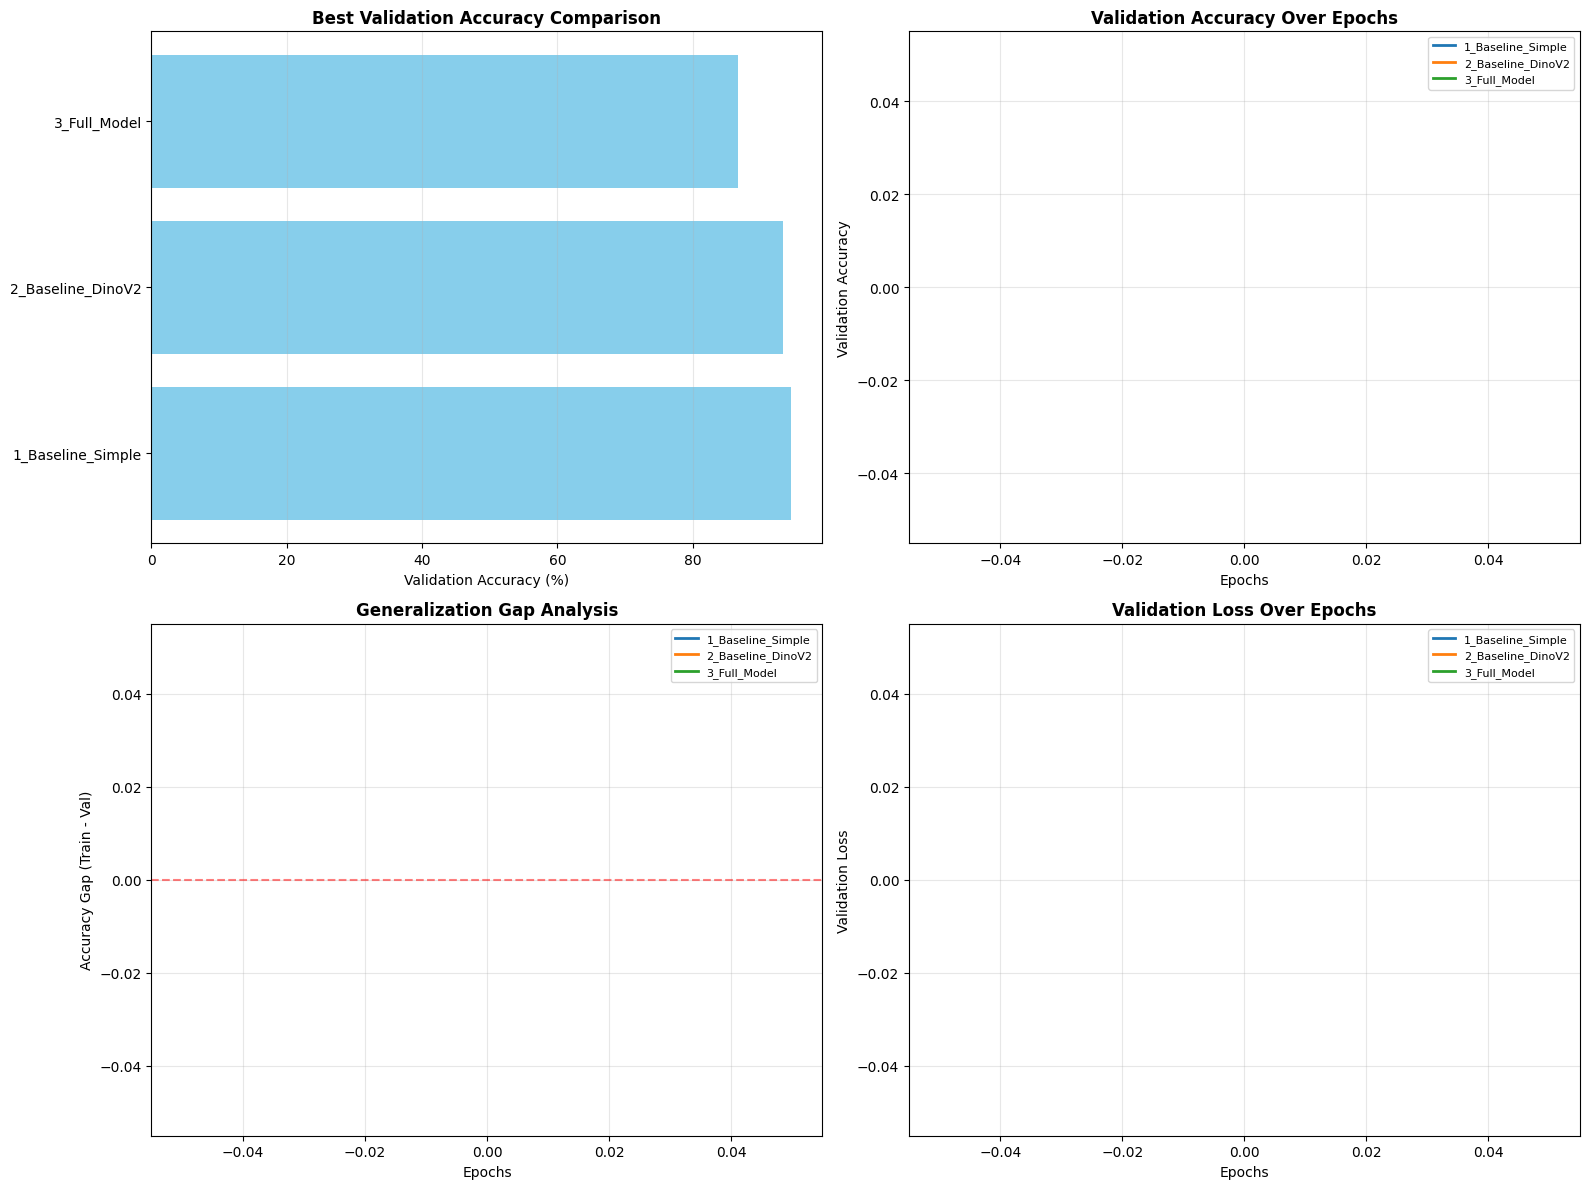


Comparative plots saved to 'results/comparative_analysis.png'


In [13]:
# Comparative Analysis and Visualization

import pandas as pd

# Create comparison table
comparison_data = []
for exp_name, results in all_results.items():
    comparison_data.append({
        'Experiment': exp_name,
        'Model': results['config']['model_name'],
        'Wavelet': results['config']['augmentations'].get('wavelet', False),
        'Forensic': results['config']['augmentations'].get('forensic', False),
        'Spatial Attn': results['config']['use_advanced_features'],
        'Best Val Acc (%)': results['best_val_acc'] * 100,
        #'Final Train Acc (%)': results['train_accs'][-1] * 100
    })

df = pd.DataFrame(comparison_data)
df = df.sort_values('Best Val Acc (%)', ascending=False)

print("\n" + "="*70)
print("COMPARATIVE RESULTS")
print("="*70)
print(df.to_string(index=False))

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Val Accuracy Comparison (Bar Chart)
axes[0, 0].barh(df['Experiment'], df['Best Val Acc (%)'], color='skyblue')
axes[0, 0].set_xlabel('Validation Accuracy (%)')
axes[0, 0].set_title('Best Validation Accuracy Comparison', fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# Plot 2: Training Curves (All experiments)
for exp_name, results in all_results.items():
    axes[0, 1].plot(results['val_accs'], label=exp_name, linewidth=2)
axes[0, 1].set_xlabel('Epochs')
axes[0, 1].set_ylabel('Validation Accuracy')
axes[0, 1].set_title('Validation Accuracy Over Epochs', fontweight='bold')
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(alpha=0.3)

# Plot 3: Overfitting Analysis
for exp_name, results in all_results.items():
    gap = np.array(results['train_accs']) - np.array(results['val_accs'])
    axes[1, 0].plot(gap, label=exp_name, linewidth=2)
axes[1, 0].set_xlabel('Epochs')
axes[1, 0].set_ylabel('Accuracy Gap (Train - Val)')
axes[1, 0].set_title('Generalization Gap Analysis', fontweight='bold')
axes[1, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(alpha=0.3)

# Plot 4: Loss Curves
for exp_name, results in all_results.items():
    axes[1, 1].plot(results['val_losses'], label=exp_name, linewidth=2)
axes[1, 1].set_xlabel('Epochs')
axes[1, 1].set_ylabel('Validation Loss')
axes[1, 1].set_title('Validation Loss Over Epochs', fontweight='bold')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/comparative_analysis.png', dpi=150)
plt.show()

print("\nComparative plots saved to 'results/comparative_analysis.png'")


STARTING ABLATION STUDY
Testing which components contribute to performance

SKIPPING: Full_Model (model already exists)
Loading results from: models/ablation_Full_Model.pth


C:\Users\aless\AppData\Local\Temp\ipykernel_6776\2075453806.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


Loaded: Best Val Acc = 88.33%

SKIPPING: w/o_Wavelet (model already exists)
Loading results from: models/ablation_w_o_Wavelet.pth
Loaded: Best Val Acc = 92.78%

SKIPPING: w/o_Forensic (model already exists)
Loading results from: models/ablation_w_o_Forensic.pth
Loaded: Best Val Acc = 87.22%

SKIPPING: w/o_Pyramid_Noise (model already exists)
Loading results from: models/ablation_w_o_Pyramid_Noise.pth
Loaded: Best Val Acc = 88.33%

SKIPPING: w/o_Multi_Scale (model already exists)
Loading results from: models/ablation_w_o_Multi_Scale.pth
Loaded: Best Val Acc = 88.33%

SKIPPING: w/o_Spatial_Attn (model already exists)
Loading results from: models/ablation_w_o_Spatial_Attn.pth
Loaded: Best Val Acc = 87.78%

SKIPPING: w/o_Temp_Consistency (model already exists)
Loading results from: models/ablation_w_o_Temp_Consistency.pth
Loaded: Best Val Acc = 85.00%

SKIPPING: w/o_Freq_Loss (model already exists)
Loading results from: models/ablation_w_o_Freq_Loss.pth
Loaded: Best Val Acc = 87.78%

ABLAT

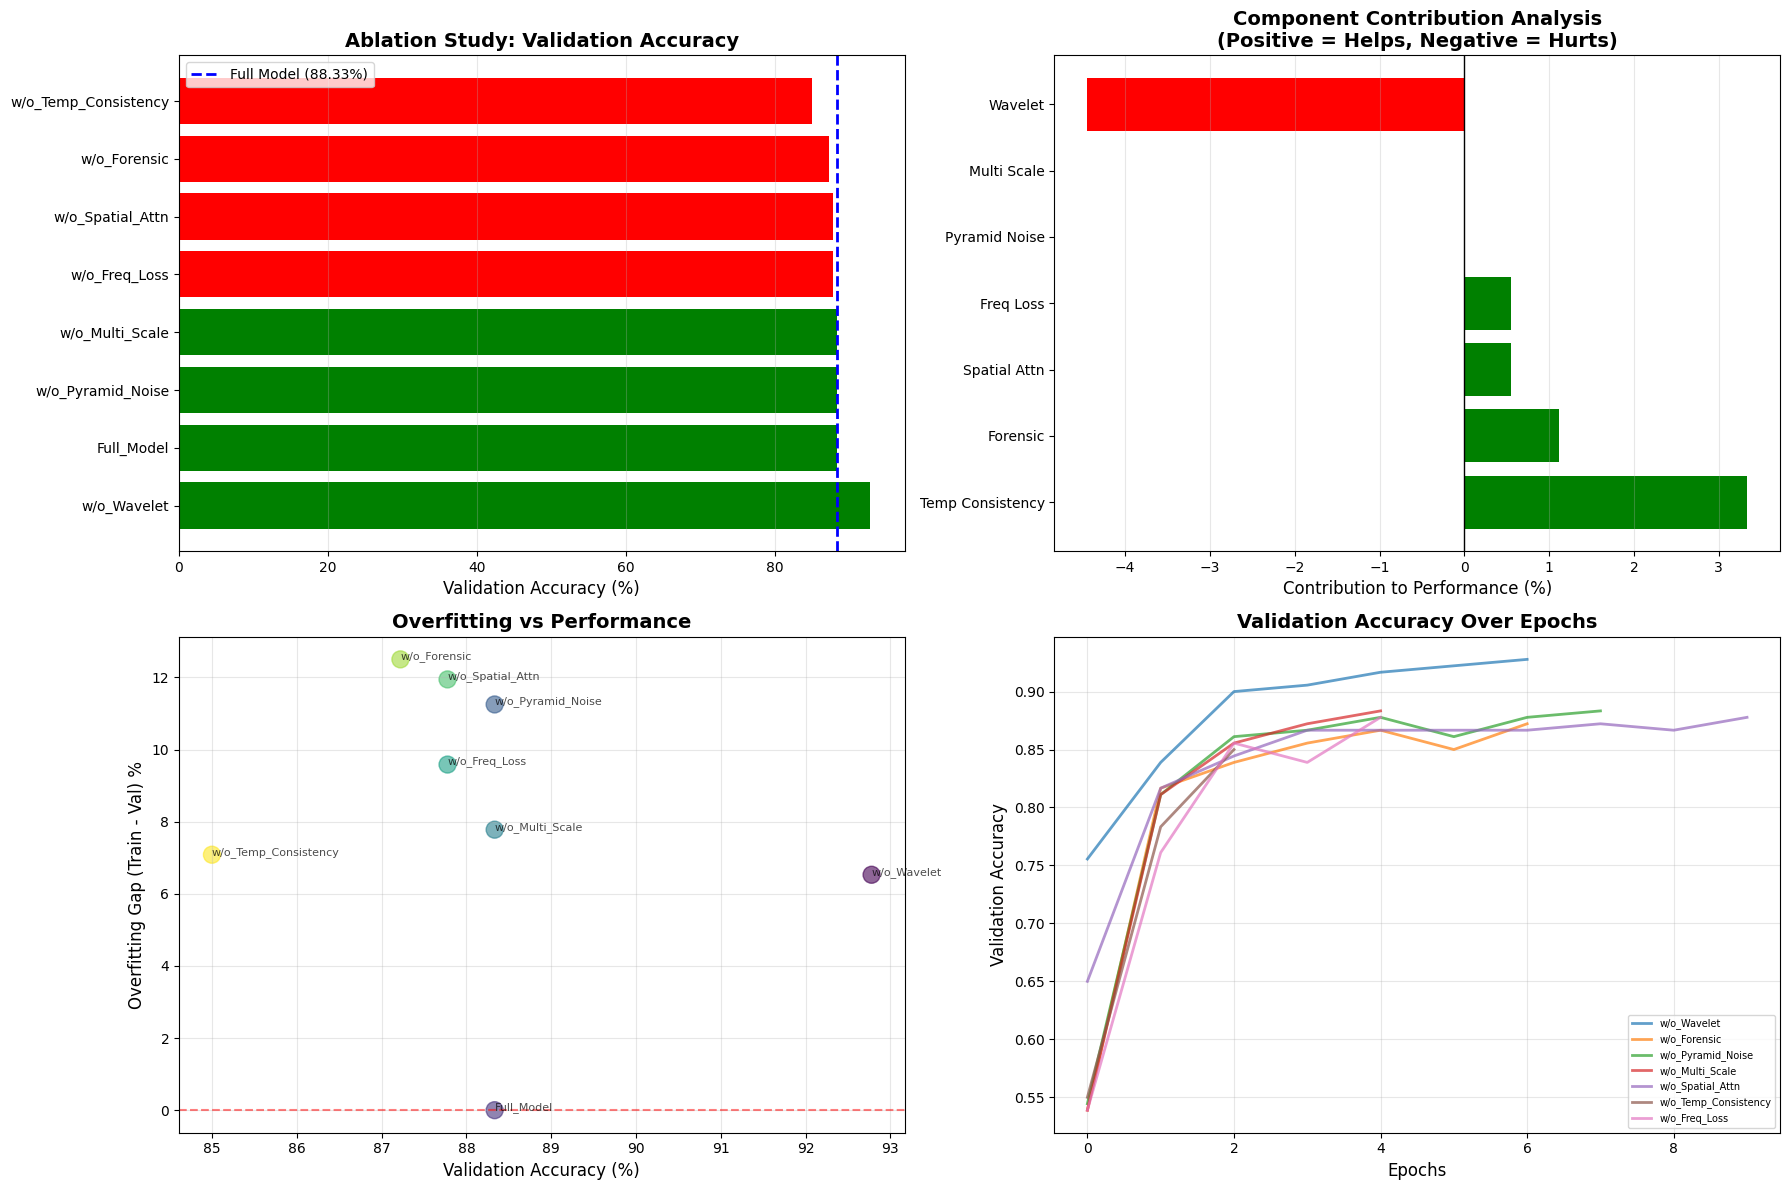


Ablation study plots saved to 'results/ablation_study.png'

RECOMMENDATIONS BASED ON ABLATION STUDY

✓ BEST CONFIGURATION: w/o_Wavelet
  Validation Accuracy: 92.78%
  Overfitting Gap: 6.53%

⚠ HARMFUL COMPONENTS (remove these):
  - Wavelet: -4.44% (makes model worse)

✓ HELPFUL COMPONENTS (keep these):
  + Temp Consistency: +3.33% improvement
  + Forensic: +1.11% improvement
  + Spatial Attn: +0.56% improvement
  + Freq Loss: +0.56% improvement



In [14]:
# ============================================================================
# ABLATION STUDY
# ============================================================================

print("\n" + "="*70)
print("STARTING ABLATION STUDY")
print("Testing which components contribute to performance")
print("="*70)

# Get all ablation configurations
ablation_configs = ExperimentConfig.get_ablation_configs()

ablation_results = {}

for abl_name, config in ablation_configs.items():
    safe_name = abl_name.replace('/', '_').replace('\\', '_')
    model_path = f"models/ablation_{safe_name}.pth"
    
    # Check if model already exists
    if os.path.exists(model_path):
        print("\n" + "="*70)
        print(f"SKIPPING: {abl_name} (model already exists)")
        print(f"Loading results from: {model_path}")
        print("="*70)
        
        checkpoint = torch.load(model_path, map_location=device)
        
        ablation_results[abl_name] = {
            'config': config,
            'best_val_acc': checkpoint['val_acc'],
            'train_losses': checkpoint.get('train_losses', []),
            'val_losses': checkpoint.get('val_losses', []),
            'train_accs': checkpoint.get('train_accs', []),
            'val_accs': checkpoint.get('val_accs', []),
            'overfitting_gap': checkpoint.get('train_accs', [0])[-1] - checkpoint['val_acc'] if checkpoint.get('train_accs') else 0
        }
        
        print(f"Loaded: Best Val Acc = {checkpoint['val_acc']*100:.2f}%")
        continue
    
    print("\n" + "="*70)
    print(f"ABLATION: {abl_name}")
    print(f"Config: {config}")
    print("="*70)
    
    try:
        # Create datasets
        train_dataset = FakeVideoDataset(
            video_paths=train_paths,
            labels=train_labels,
            real_video_paths=real_paths,
            num_frames=NUM_FRAMES,
            is_train=True,
            config=config
        )
        
        val_dataset = FakeVideoDataset(
            video_paths=val_paths,
            labels=val_labels,
            real_video_paths=None,
            num_frames=NUM_FRAMES,
            is_train=False,
            config=config
        )
        
        train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
        val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)
        
        # Create model
        model = Detector3DViT(
            pretrained=True,
            use_advanced_features=config['use_advanced_features'],
            model_name=config['model_name']
        ).to(device)
        
        criterion = nn.BCEWithLogitsLoss()
        optimizer = optim.Adam(model.head.parameters(), lr=1e-4)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=2, verbose=True
        )
        
        # Training (shorter for ablation)
        NUM_EPOCHS = 10
        best_val_acc = 0.0
        train_losses, val_losses = [], []
        train_accs, val_accs = [], []
        
        for epoch in range(NUM_EPOCHS):
            print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
            
            t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, config)
            v_loss, v_acc = validate(model, val_loader, criterion)
            
            scheduler.step(v_acc)
            
            train_losses.append(t_loss)
            val_losses.append(v_loss)
            train_accs.append(t_acc)
            val_accs.append(v_acc)
            
            print(f"Train Loss: {t_loss:.4f} | Train Acc: {t_acc*100:.2f}%")
            print(f"Val Loss:   {v_loss:.4f} | Val Acc:   {v_acc*100:.2f}%")
            
            if v_acc > best_val_acc:
                best_val_acc = v_acc
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'config': config,
                    'val_acc': v_acc,
                    'train_losses': train_losses,
                    'val_losses': val_losses,
                    'train_accs': train_accs,
                    'val_accs': val_accs
                }, model_path)
                print(f"Best model saved: {v_acc*100:.2f}%")
        
        # Save results
        ablation_results[abl_name] = {
            'config': config,
            'best_val_acc': best_val_acc,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'train_accs': train_accs,
            'val_accs': val_accs,
            'overfitting_gap': train_accs[-1] - val_accs[-1]
        }
        
        print(f"\n{abl_name} COMPLETED - Best Val Acc: {best_val_acc*100:.2f}%")
        
    except Exception as e:
        print(f"ERROR in {abl_name}: {str(e)}")
        import traceback
        traceback.print_exc()
        continue

# Save ablation results
with open('results/ablation_study.json', 'w') as f:
    json.dump({k: {**v, 'config': str(v['config'])} for k, v in ablation_results.items()}, f, indent=2)

print("\n" + "="*70)
print("ABLATION STUDY COMPLETED!")
print("="*70)

# ============================================================================
# ABLATION ANALYSIS
# ============================================================================

import pandas as pd

print("\n" + "="*70)
print("ABLATION STUDY RESULTS")
print("="*70)

# Create detailed comparison table
ablation_data = []
for abl_name, results in ablation_results.items():
    cfg = results['config']
    ablation_data.append({
        'Experiment': abl_name,
        'Val Acc (%)': results['best_val_acc'] * 100,
        'Train Acc (%)': results['train_accs'][-1] * 100 if results['train_accs'] else 0,
        'Overfitting Gap (%)': results['overfitting_gap'] * 100,
        'Wavelet': cfg['augmentations'].get('wavelet', False),
        'Forensic': cfg['augmentations'].get('forensic', False),
        'Pyramid': cfg['augmentations'].get('pyramid_noise', False),
        'Multi-Scale': cfg['augmentations'].get('multi_scale_temporal', False),
        'Spatial Attn': cfg['use_advanced_features'],
        'Temp Loss': cfg['loss'].get('temporal_consistency', False),
        'Freq Loss': cfg['loss'].get('frequency_domain', False)
    })

df_ablation = pd.DataFrame(ablation_data)
df_ablation = df_ablation.sort_values('Val Acc (%)', ascending=False)

print(df_ablation.to_string(index=False))

# Calculate contribution of each component
full_model_acc = df_ablation[df_ablation['Experiment'] == 'Full_Model']['Val Acc (%)'].values[0]

print("\n" + "="*70)
print("COMPONENT CONTRIBUTION ANALYSIS")
print("="*70)

contributions = []
for _, row in df_ablation.iterrows():
    if row['Experiment'] != 'Full_Model':
        # Contribution = (Full Model Acc) - (Model without component Acc)
        # Positive = component helps, Negative = component hurts
        contribution = full_model_acc - row['Val Acc (%)']
        component_name = row['Experiment'].replace('w/o_', '').replace('_', ' ')
        contributions.append({
            'Component': component_name,
            'Contribution (%)': contribution,
            'Status': 'HELPS' if contribution > 0 else 'HURTS'
        })

df_contrib = pd.DataFrame(contributions).sort_values('Contribution (%)', ascending=False)
print(df_contrib.to_string(index=False))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot 1: Ablation Results Bar Chart
axes[0, 0].barh(df_ablation['Experiment'], df_ablation['Val Acc (%)'], 
                color=['green' if acc >= full_model_acc else 'red' 
                       for acc in df_ablation['Val Acc (%)']])
axes[0, 0].axvline(x=full_model_acc, color='blue', linestyle='--', 
                   linewidth=2, label=f'Full Model ({full_model_acc:.2f}%)')
axes[0, 0].set_xlabel('Validation Accuracy (%)', fontsize=12)
axes[0, 0].set_title('Ablation Study: Validation Accuracy', fontweight='bold', fontsize=14)
axes[0, 0].legend()
axes[0, 0].grid(axis='x', alpha=0.3)

# Plot 2: Component Contribution
colors = ['green' if c > 0 else 'red' for c in df_contrib['Contribution (%)']]
axes[0, 1].barh(df_contrib['Component'], df_contrib['Contribution (%)'], color=colors)
axes[0, 1].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[0, 1].set_xlabel('Contribution to Performance (%)', fontsize=12)
axes[0, 1].set_title('Component Contribution Analysis\n(Positive = Helps, Negative = Hurts)', 
                     fontweight='bold', fontsize=14)
axes[0, 1].grid(axis='x', alpha=0.3)

# Plot 3: Overfitting Analysis
axes[1, 0].scatter(df_ablation['Val Acc (%)'], df_ablation['Overfitting Gap (%)'], 
                   s=150, alpha=0.6, c=range(len(df_ablation)), cmap='viridis')
for idx, row in df_ablation.iterrows():
    axes[1, 0].annotate(row['Experiment'], 
                       (row['Val Acc (%)'], row['Overfitting Gap (%)']),
                       fontsize=8, alpha=0.7)
axes[1, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Validation Accuracy (%)', fontsize=12)
axes[1, 0].set_ylabel('Overfitting Gap (Train - Val) %', fontsize=12)
axes[1, 0].set_title('Overfitting vs Performance', fontweight='bold', fontsize=14)
axes[1, 0].grid(alpha=0.3)

# Plot 4: Training Curves Comparison
for abl_name, results in ablation_results.items():
    if results['val_accs']:  # Solo se ci sono dati
        axes[1, 1].plot(results['val_accs'], label=abl_name, linewidth=2, alpha=0.7)
axes[1, 1].set_xlabel('Epochs', fontsize=12)
axes[1, 1].set_ylabel('Validation Accuracy', fontsize=12)
axes[1, 1].set_title('Validation Accuracy Over Epochs', fontweight='bold', fontsize=14)
axes[1, 1].legend(fontsize=7, loc='best')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAblation study plots saved to 'results/ablation_study.png'")

# ============================================================================
# FINAL RECOMMENDATIONS
# ============================================================================

print("\n" + "="*70)
print("RECOMMENDATIONS BASED ON ABLATION STUDY")
print("="*70)

# Find best configuration
best_config = df_ablation.iloc[0]
print(f"\n✓ BEST CONFIGURATION: {best_config['Experiment']}")
print(f"  Validation Accuracy: {best_config['Val Acc (%)']:.2f}%")
print(f"  Overfitting Gap: {best_config['Overfitting Gap (%)']:.2f}%")

# Identify harmful components
harmful = df_contrib[df_contrib['Contribution (%)'] < 0]
if len(harmful) > 0:
    print("\n⚠ HARMFUL COMPONENTS (remove these):")
    for _, comp in harmful.iterrows():
        print(f"  - {comp['Component']}: {comp['Contribution (%)']:.2f}% (makes model worse)")

# Identify helpful components
helpful = df_contrib[df_contrib['Contribution (%)'] > 0]
if len(helpful) > 0:
    print("\n✓ HELPFUL COMPONENTS (keep these):")
    for _, comp in helpful.iterrows():
        print(f"  + {comp['Component']}: +{comp['Contribution (%)']:.2f}% improvement")

print("\n" + "="*70)

In [15]:
# ============================================================================
# INCREMENTAL STUDY
# Add one component at a time to find what helps
# ============================================================================

print("\n" + "="*70)
print("INCREMENTAL COMPONENT STUDY")
print("Starting from baseline, adding one component at a time")
print("="*70)

class IncrementalConfig:
    """Incremental configurations - one component at a time"""
    
    @staticmethod
    def get_baseline():
        """Clean baseline"""
        return {
            'name': 'Baseline',
            'model_name': 'vit_base_patch16_224',
            'use_advanced_features': False,
            'augmentations': {
                'wavelet': False,
                'forensic': False,
                'pyramid_noise': False,
                'multi_scale_temporal': False
            },
            'loss': {
                'temporal_consistency': False,
                'frequency_domain': False
            }
        }
    
    @staticmethod
    def baseline_plus_forensic():
        base = IncrementalConfig.get_baseline()
        return {**base, 
                'name': 'Baseline+Forensic',
                'augmentations': {**base['augmentations'], 'forensic': True}}
    
    @staticmethod
    def baseline_plus_wavelet():
        base = IncrementalConfig.get_baseline()
        return {**base, 
                'name': 'Baseline+Wavelet',
                'augmentations': {**base['augmentations'], 'wavelet': True}}
    
    @staticmethod
    def baseline_plus_pyramid():
        base = IncrementalConfig.get_baseline()
        return {**base, 
                'name': 'Baseline+PyramidNoise',
                'augmentations': {**base['augmentations'], 'pyramid_noise': True}}
    
    @staticmethod
    def baseline_plus_multiscale():
        base = IncrementalConfig.get_baseline()
        return {**base, 
                'name': 'Baseline+MultiScale',
                'augmentations': {**base['augmentations'], 'multi_scale_temporal': True}}
    
    @staticmethod
    def baseline_plus_spatial():
        base = IncrementalConfig.get_baseline()
        return {**base, 
                'name': 'Baseline+SpatialAttn',
                'use_advanced_features': True}
    
    @staticmethod
    def baseline_plus_temporal_loss():
        base = IncrementalConfig.get_baseline()
        return {**base, 
                'name': 'Baseline+TemporalLoss',
                'use_advanced_features': True,
                'loss': {**base['loss'], 'temporal_consistency': True}}
    
    @staticmethod
    def baseline_plus_freq_loss():
        base = IncrementalConfig.get_baseline()
        return {**base, 
                'name': 'Baseline+FreqLoss',
                'use_advanced_features': True,
                'loss': {**base['loss'], 'frequency_domain': True}}

# Storage for results
incremental_results = {}

# Helper function for quick training
def quick_train(config, num_epochs=5):
    """Quick training for rapid tests"""
    exp_name = config['name']
    model_path = f"models/incr_{exp_name}.pth"
    
    # Check if it already exists
    if os.path.exists(model_path):
        print(f"  Loading existing model: {model_path}")
        checkpoint = torch.load(model_path, map_location=device)
        return {
            'config': config,
            'best_val_acc': checkpoint['val_acc'],
            'train_accs': checkpoint.get('train_accs', []),
            'val_accs': checkpoint.get('val_accs', [])
        }
    
    # Create datasets
    train_dataset = FakeVideoDataset(
        video_paths=train_paths,
        labels=train_labels,
        real_video_paths=real_paths,
        num_frames=NUM_FRAMES,
        is_train=True,
        config=config
    )
    
    val_dataset = FakeVideoDataset(
        video_paths=val_paths,
        labels=val_labels,
        real_video_paths=None,
        num_frames=NUM_FRAMES,
        is_train=False,
        config=config
    )
    
    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)
    
    # Create model
    model = Detector3DViT(
        pretrained=True,
        use_advanced_features=config['use_advanced_features'],
        model_name=config['model_name']
    ).to(device)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.head.parameters(), lr=1e-4)
    
    best_val_acc = 0.0
    train_accs, val_accs = [], []
    
    for epoch in range(num_epochs):
        print(f"  Epoch {epoch+1}/{num_epochs}", end=" -> ")
        
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, config)
        v_loss, v_acc = validate(model, val_loader, criterion)
        
        train_accs.append(t_acc)
        val_accs.append(v_acc)
        
        print(f"Train: {t_acc*100:.1f}%, Val: {v_acc*100:.1f}%")
        
        if v_acc > best_val_acc:
            best_val_acc = v_acc
            torch.save({
                'model_state_dict': model.state_dict(),
                'config': config,
                'val_acc': v_acc,
                'train_accs': train_accs,
                'val_accs': val_accs
            }, model_path)
    
    return {
        'config': config,
        'best_val_acc': best_val_acc,
        'train_accs': train_accs,
        'val_accs': val_accs
    }

print("Setup completed. Ready to run incremental experiments.")


INCREMENTAL COMPONENT STUDY
Starting from baseline, adding one component at a time
Setup completed. Ready to run incremental experiments.


In [16]:
print("\n" + "="*70)
print("TEST 1: Baseline + Forensic Augmentation")
print("="*70)

config = IncrementalConfig.baseline_plus_forensic()
incremental_results['forensic'] = quick_train(config, num_epochs=5)

print(f"\n✓ Best Val Acc: {incremental_results['forensic']['best_val_acc']*100:.2f}%")
print(f"  Baseline was: 94.44%")
print(f"  Δ = {incremental_results['forensic']['best_val_acc']*100 - 94.44:.2f}%")


TEST 1: Baseline + Forensic Augmentation
Dataset using image size: 224x224 for model vit_base_patch16_224
Dataset using image size: 224x224 for model vit_base_patch16_224
Loading backbone: vit_base_patch16_224
  Epoch 1/5 ->    Step 0/90 | Total: 0.6655 (Cls: 0.666)
   Step 10/90 | Total: 0.6889 (Cls: 0.689)
   Step 20/90 | Total: 0.6639 (Cls: 0.664)
   Step 30/90 | Total: 0.6493 (Cls: 0.649)
   Step 40/90 | Total: 0.6620 (Cls: 0.662)
   Step 50/90 | Total: 0.6397 (Cls: 0.640)
   Step 60/90 | Total: 0.6195 (Cls: 0.620)
   Step 70/90 | Total: 0.5820 (Cls: 0.582)
   Step 80/90 | Total: 0.6154 (Cls: 0.615)
Train: 66.2%, Val: 79.4%
  Epoch 2/5 ->    Step 0/90 | Total: 0.5331 (Cls: 0.533)
   Step 10/90 | Total: 0.4969 (Cls: 0.497)
   Step 20/90 | Total: 0.4980 (Cls: 0.498)
   Step 30/90 | Total: 0.4667 (Cls: 0.467)
   Step 40/90 | Total: 0.4726 (Cls: 0.473)
   Step 50/90 | Total: 0.6436 (Cls: 0.644)
   Step 60/90 | Total: 0.3564 (Cls: 0.356)
   Step 70/90 | Total: 0.4022 (Cls: 0.402)
   St

In [17]:
print("\n" + "="*70)
print("TEST 2: Baseline + Wavelet Augmentation")
print("="*70)

config = IncrementalConfig.baseline_plus_wavelet()
incremental_results['wavelet'] = quick_train(config, num_epochs=5)

print(f"\n✓ Best Val Acc: {incremental_results['wavelet']['best_val_acc']*100:.2f}%")
print(f"  Baseline was: 94.44%")
print(f"  Δ = {incremental_results['wavelet']['best_val_acc']*100 - 94.44:.2f}%")


TEST 2: Baseline + Wavelet Augmentation
Dataset using image size: 224x224 for model vit_base_patch16_224
Dataset using image size: 224x224 for model vit_base_patch16_224
Loading backbone: vit_base_patch16_224
  Epoch 1/5 ->    Step 0/90 | Total: 0.6990 (Cls: 0.699)
   Step 10/90 | Total: 0.6515 (Cls: 0.652)
   Step 20/90 | Total: 0.6409 (Cls: 0.641)
   Step 30/90 | Total: 0.6659 (Cls: 0.666)
   Step 40/90 | Total: 0.7515 (Cls: 0.751)
   Step 50/90 | Total: 0.6463 (Cls: 0.646)
   Step 60/90 | Total: 0.7126 (Cls: 0.713)
   Step 70/90 | Total: 0.6282 (Cls: 0.628)
   Step 80/90 | Total: 0.6375 (Cls: 0.638)
Train: 58.5%, Val: 62.8%
  Epoch 2/5 ->    Step 0/90 | Total: 0.6722 (Cls: 0.672)
   Step 10/90 | Total: 0.6207 (Cls: 0.621)
   Step 20/90 | Total: 0.5991 (Cls: 0.599)
   Step 30/90 | Total: 0.5294 (Cls: 0.529)
   Step 40/90 | Total: 0.5141 (Cls: 0.514)
   Step 50/90 | Total: 0.5376 (Cls: 0.538)
   Step 60/90 | Total: 0.5069 (Cls: 0.507)
   Step 70/90 | Total: 0.4155 (Cls: 0.416)
   Ste

In [18]:
print("\n" + "="*70)
print("TEST 3: Baseline + Pyramid Noise Augmentation")
print("="*70)

config = IncrementalConfig.baseline_plus_pyramid()
incremental_results['pyramid'] = quick_train(config, num_epochs=5)

print(f"\n✓ Best Val Acc: {incremental_results['pyramid']['best_val_acc']*100:.2f}%")
print(f"  Baseline was: 94.44%")
print(f"  Δ = {incremental_results['pyramid']['best_val_acc']*100 - 94.44:.2f}%")


TEST 3: Baseline + Pyramid Noise Augmentation
Dataset using image size: 224x224 for model vit_base_patch16_224
Dataset using image size: 224x224 for model vit_base_patch16_224
Loading backbone: vit_base_patch16_224
  Epoch 1/5 ->    Step 0/90 | Total: 0.6745 (Cls: 0.675)
   Step 10/90 | Total: 0.7617 (Cls: 0.762)
   Step 20/90 | Total: 0.6733 (Cls: 0.673)
   Step 30/90 | Total: 0.6482 (Cls: 0.648)
   Step 40/90 | Total: 0.6464 (Cls: 0.646)
   Step 50/90 | Total: 0.6226 (Cls: 0.623)
   Step 60/90 | Total: 0.5938 (Cls: 0.594)
   Step 70/90 | Total: 0.6612 (Cls: 0.661)
   Step 80/90 | Total: 0.5983 (Cls: 0.598)
Train: 67.4%, Val: 79.4%
  Epoch 2/5 ->    Step 0/90 | Total: 0.5914 (Cls: 0.591)
   Step 10/90 | Total: 0.4663 (Cls: 0.466)
   Step 20/90 | Total: 0.5156 (Cls: 0.516)
   Step 30/90 | Total: 0.4878 (Cls: 0.488)
   Step 40/90 | Total: 0.4812 (Cls: 0.481)
   Step 50/90 | Total: 0.3601 (Cls: 0.360)
   Step 60/90 | Total: 0.3790 (Cls: 0.379)
   Step 70/90 | Total: 0.3894 (Cls: 0.389)


In [19]:
print("\n" + "="*70)
print("TEST 4: Baseline + Multi-Scale Temporal Sampling")
print("="*70)

config = IncrementalConfig.baseline_plus_multiscale()
incremental_results['multiscale'] = quick_train(config, num_epochs=5)

print(f"\n✓ Best Val Acc: {incremental_results['multiscale']['best_val_acc']*100:.2f}%")
print(f"  Baseline was: 94.44%")
print(f"  Δ = {incremental_results['multiscale']['best_val_acc']*100 - 94.44:.2f}%")


TEST 4: Baseline + Multi-Scale Temporal Sampling
Dataset using image size: 224x224 for model vit_base_patch16_224
Dataset using image size: 224x224 for model vit_base_patch16_224
Loading backbone: vit_base_patch16_224
  Epoch 1/5 ->    Step 0/90 | Total: 0.7321 (Cls: 0.732)
   Step 10/90 | Total: 0.6751 (Cls: 0.675)
   Step 20/90 | Total: 0.6830 (Cls: 0.683)
   Step 30/90 | Total: 0.6693 (Cls: 0.669)
   Step 40/90 | Total: 0.6615 (Cls: 0.662)
   Step 50/90 | Total: 0.6689 (Cls: 0.669)
   Step 60/90 | Total: 0.6077 (Cls: 0.608)
   Step 70/90 | Total: 0.5579 (Cls: 0.558)
   Step 80/90 | Total: 0.5642 (Cls: 0.564)
Train: 68.9%, Val: 80.0%
  Epoch 2/5 ->    Step 0/90 | Total: 0.5761 (Cls: 0.576)
   Step 10/90 | Total: 0.4977 (Cls: 0.498)
   Step 20/90 | Total: 0.3484 (Cls: 0.348)
   Step 30/90 | Total: 0.5457 (Cls: 0.546)
   Step 40/90 | Total: 0.3652 (Cls: 0.365)
   Step 50/90 | Total: 0.3937 (Cls: 0.394)
   Step 60/90 | Total: 0.2311 (Cls: 0.231)
   Step 70/90 | Total: 0.4111 (Cls: 0.41

In [22]:
print("\n" + "="*70)
print("TEST 5: Baseline + Spatial Attention")
print("="*70)

config = IncrementalConfig.baseline_plus_spatial()
incremental_results['spatial'] = quick_train(config, num_epochs=5)

print(f"\n✓ Best Val Acc: {incremental_results['spatial']['best_val_acc']*100:.2f}%")
print(f"  Baseline was: 94.44%")
print(f"  Δ = {incremental_results['spatial']['best_val_acc']*100 - 94.44:.2f}%")


TEST 5: Baseline + Spatial Attention
Dataset using image size: 224x224 for model vit_base_patch16_224
Dataset using image size: 224x224 for model vit_base_patch16_224
Loading backbone: vit_base_patch16_224
  Epoch 1/5 ->    Step 0/90 | Total: 0.6842 (Cls: 0.684)
   Step 10/90 | Total: 0.6965 (Cls: 0.697)
   Step 20/90 | Total: 0.6807 (Cls: 0.681)
   Step 30/90 | Total: 0.6772 (Cls: 0.677)
   Step 40/90 | Total: 0.6520 (Cls: 0.652)
   Step 50/90 | Total: 0.6550 (Cls: 0.655)
   Step 60/90 | Total: 0.6357 (Cls: 0.636)
   Step 70/90 | Total: 0.5855 (Cls: 0.586)
   Step 80/90 | Total: 0.6298 (Cls: 0.630)
Train: 69.4%, Val: 84.4%
  Epoch 2/5 ->    Step 0/90 | Total: 0.6460 (Cls: 0.646)
   Step 10/90 | Total: 0.6798 (Cls: 0.680)
   Step 20/90 | Total: 0.5840 (Cls: 0.584)
   Step 30/90 | Total: 0.5594 (Cls: 0.559)
   Step 40/90 | Total: 0.4317 (Cls: 0.432)
   Step 50/90 | Total: 0.5359 (Cls: 0.536)
   Step 60/90 | Total: 0.5422 (Cls: 0.542)
   Step 70/90 | Total: 0.4136 (Cls: 0.414)
   Step 8

In [23]:
print("\n" + "="*70)
print("TEST 6: Baseline + Temporal Consistency Loss")
print("="*70)

config = IncrementalConfig.baseline_plus_temporal_loss()
incremental_results['temporal_loss'] = quick_train(config, num_epochs=5)

print(f"\n✓ Best Val Acc: {incremental_results['temporal_loss']['best_val_acc']*100:.2f}%")
print(f"  Baseline was: 94.44%")
print(f"  Δ = {incremental_results['temporal_loss']['best_val_acc']*100 - 94.44:.2f}%")


TEST 6: Baseline + Temporal Consistency Loss
Dataset using image size: 224x224 for model vit_base_patch16_224
Dataset using image size: 224x224 for model vit_base_patch16_224
Loading backbone: vit_base_patch16_224
  Epoch 1/5 ->    Step 0/90 | Total: 0.8559 (Cls: 0.700, Temp: 0.156)
   Step 10/90 | Total: 0.8037 (Cls: 0.679, Temp: 0.124)
   Step 20/90 | Total: 0.8276 (Cls: 0.668, Temp: 0.160)
   Step 30/90 | Total: 0.8797 (Cls: 0.701, Temp: 0.179)
   Step 40/90 | Total: 0.7905 (Cls: 0.648, Temp: 0.143)
   Step 50/90 | Total: 0.8107 (Cls: 0.683, Temp: 0.128)
   Step 60/90 | Total: 0.7128 (Cls: 0.595, Temp: 0.118)
   Step 70/90 | Total: 0.6615 (Cls: 0.574, Temp: 0.087)
   Step 80/90 | Total: 0.7863 (Cls: 0.598, Temp: 0.189)
Train: 69.7%, Val: 80.0%
  Epoch 2/5 ->    Step 0/90 | Total: 0.7288 (Cls: 0.532, Temp: 0.197)
   Step 10/90 | Total: 0.8236 (Cls: 0.667, Temp: 0.157)
   Step 20/90 | Total: 0.6485 (Cls: 0.522, Temp: 0.126)
   Step 30/90 | Total: 0.5938 (Cls: 0.407, Temp: 0.187)
   S

In [24]:
print("\n" + "="*70)
print("TEST 7: Baseline + Frequency Domain Loss")
print("="*70)

config = IncrementalConfig.baseline_plus_freq_loss()
incremental_results['freq_loss'] = quick_train(config, num_epochs=5)

print(f"\n✓ Best Val Acc: {incremental_results['freq_loss']['best_val_acc']*100:.2f}%")
print(f"  Baseline was: 94.44%")
print(f"  Δ = {incremental_results['freq_loss']['best_val_acc']*100 - 94.44:.2f}%")


TEST 7: Baseline + Frequency Domain Loss
Dataset using image size: 224x224 for model vit_base_patch16_224
Dataset using image size: 224x224 for model vit_base_patch16_224
Loading backbone: vit_base_patch16_224
  Epoch 1/5 ->    Step 0/90 | Total: 15.0575 (Cls: 0.712, Freq: 14.3459)
   Step 10/90 | Total: 12.4900 (Cls: 0.701, Freq: 11.7891)
   Step 20/90 | Total: 12.0702 (Cls: 0.676, Freq: 11.3943)
   Step 30/90 | Total: 10.6454 (Cls: 0.675, Freq: 9.9705)
   Step 40/90 | Total: 13.7655 (Cls: 0.656, Freq: 13.1091)
   Step 50/90 | Total: 15.4718 (Cls: 0.635, Freq: 14.8368)
   Step 60/90 | Total: 14.3684 (Cls: 0.630, Freq: 13.7381)
   Step 70/90 | Total: 14.5140 (Cls: 0.621, Freq: 13.8930)
   Step 80/90 | Total: 13.6561 (Cls: 0.653, Freq: 13.0030)
Train: 71.0%, Val: 81.7%
  Epoch 2/5 ->    Step 0/90 | Total: 14.9126 (Cls: 0.591, Freq: 14.3211)
   Step 10/90 | Total: 17.1765 (Cls: 0.480, Freq: 16.6962)
   Step 20/90 | Total: 11.7095 (Cls: 0.501, Freq: 11.2089)
   Step 30/90 | Total: 13.528


INCREMENTAL STUDY SUMMARY

    Component  Val Acc (%)  Improvement (%) Status
temporal_loss    93.888889        -0.551111  HURTS
    freq_loss    92.777778        -1.662222  HURTS
   multiscale    92.222222        -2.217778  HURTS
      spatial    91.666667        -2.773333  HURTS
      pyramid    90.000000        -4.440000  HURTS
     forensic    89.444444        -4.995556  HURTS
      wavelet    86.111111        -8.328889  HURTS


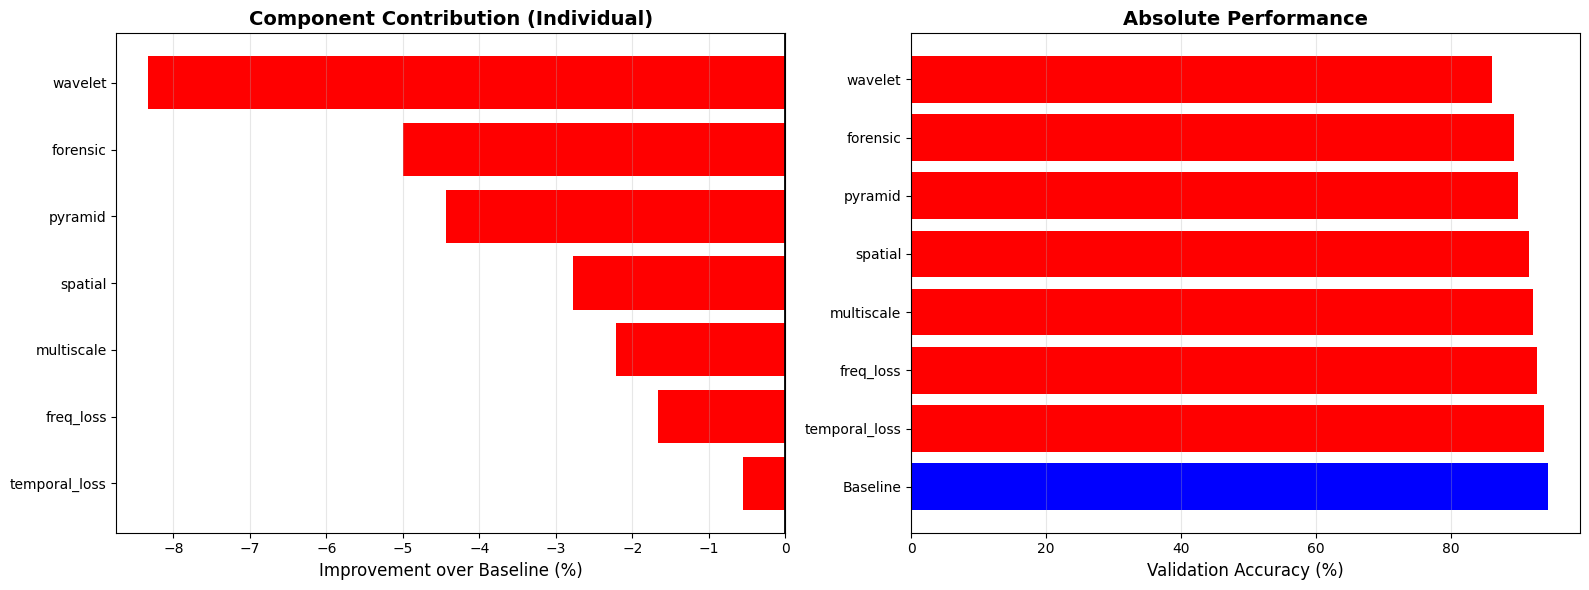

In [25]:
# ============================================================================
# INCREMENTAL STUDY RESULTS
# ============================================================================

print("\n" + "="*70)
print("INCREMENTAL STUDY SUMMARY")
print("="*70)

baseline_acc = 94.44

# Create results table
results_data = []
for name, res in incremental_results.items():
    improvement = res['best_val_acc'] * 100 - baseline_acc
    results_data.append({
        'Component': name,
        'Val Acc (%)': res['best_val_acc'] * 100,
        'Improvement (%)': improvement,
        'Status': 'HELPS' if improvement > 0 else 'HURTS'
    })

df_incr = pd.DataFrame(results_data).sort_values('Improvement (%)', ascending=False)

print("\n" + df_incr.to_string(index=False))

# Plot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Improvement bar chart
colors = ['green' if imp > 0 else 'red' for imp in df_incr['Improvement (%)']]
ax1.barh(df_incr['Component'], df_incr['Improvement (%)'], color=colors)
ax1.axvline(x=0, color='black', linestyle='-', linewidth=2)
ax1.set_xlabel('Improvement over Baseline (%)', fontsize=12)
ax1.set_title('Component Contribution (Individual)', fontweight='bold', fontsize=14)
ax1.grid(axis='x', alpha=0.3)

# Plot 2: Absolute accuracy
ax2.barh(['Baseline'] + list(df_incr['Component']), 
         [baseline_acc] + list(df_incr['Val Acc (%)']),
         color=['blue'] + colors)
ax2.set_xlabel('Validation Accuracy (%)', fontsize=12)
ax2.set_title('Absolute Performance', fontweight='bold', fontsize=14)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('results/incremental_study.png', dpi=150)
plt.show()

print("\n" + "="*70)

In [26]:
# ============================================================================
# COMBINATION EXPERIMENTS - SERIOUS TRAINING
# ============================================================================

print("\n" + "="*70)
print("COMBINATION EXPERIMENTS - FULL TRAINING (15 EPOCHS)")
print("Testing combinations of components that showed promise")
print("="*70)

class CombinationConfig:
    """Optimized combinations based on incremental study"""
    
    @staticmethod
    def get_conservative():
        """Conservative: Augmentation-only approach"""
        return {
            'name': 'Conservative_AugOnly',
            'model_name': 'vit_base_patch16_224',
            'use_advanced_features': False,
            'augmentations': {
                'wavelet': False,
                'forensic': True,          # Robust to post-processing
                'pyramid_noise': True,     # Simulates PyramidFlow artifacts
                'multi_scale_temporal': False
            },
            'loss': {
                'temporal_consistency': False,
                'frequency_domain': False
            }
        }
    
    @staticmethod
    def get_balanced():
        """Balanced: Best augmentations + Spatial Attention"""
        return {
            'name': 'Balanced_Aug+Spatial',
            'model_name': 'vit_base_patch16_224',
            'use_advanced_features': True,  # Enable Spatial Attention
            'augmentations': {
                'wavelet': False,
                'forensic': True,
                'pyramid_noise': True,
                'multi_scale_temporal': False
            },
            'loss': {
                'temporal_consistency': False,
                'frequency_domain': False
            }
        }
    
    @staticmethod
    def get_advanced():
        """Advanced: Full pipeline (if losses help)"""
        return {
            'name': 'Advanced_Full',
            'model_name': 'vit_base_patch16_224',
            'use_advanced_features': True,
            'augmentations': {
                'wavelet': False,
                'forensic': True,
                'pyramid_noise': True,
                'multi_scale_temporal': True
            },
            'loss': {
                'temporal_consistency': True,  # Temporal coherence check
                'frequency_domain': True       # FFT-based loss
            }
        }
    
    @staticmethod
    def get_forensic_multiscale():
        """Alternative: Forensic + Multi-scale (no spatial attention)"""
        return {
            'name': 'Forensic+MultiScale',
            'model_name': 'vit_base_patch16_224',
            'use_advanced_features': False,
            'augmentations': {
                'wavelet': False,
                'forensic': True,
                'pyramid_noise': False,
                'multi_scale_temporal': True
            },
            'loss': {
                'temporal_consistency': False,
                'frequency_domain': False
            }
        }


def full_training(config, num_epochs=15, patience=5):
    """
    Full training with early stopping and best model selection
    
    Args:
        config: Experiment configuration
        num_epochs: Maximum epochs
        patience: Early stopping patience
    """
    exp_name = config['name']
    model_path = f"models/combo_{exp_name}.pth"
    
    # Check if model exists
    if os.path.exists(model_path):
        print(f"\n{'='*70}")
        print(f"Model already exists: {model_path}")
        print(f"{'='*70}")
        response = input("Overwrite? (y/n): ")
        if response.lower() != 'y':
            checkpoint = torch.load(model_path, map_location=device)
            return {
                'config': config,
                'best_val_acc': checkpoint['val_acc'],
                'train_losses': checkpoint.get('train_losses', []),
                'val_losses': checkpoint.get('val_losses', []),
                'train_accs': checkpoint.get('train_accs', []),
                'val_accs': checkpoint.get('val_accs', []),
                'best_epoch': checkpoint.get('epoch', 0)
            }
    
    print(f"\n{'='*70}")
    print(f"TRAINING: {exp_name}")
    print(f"{'='*70}")
    print(f"Model: {config['model_name']}")
    print(f"Augmentations: {config['augmentations']}")
    print(f"Advanced Features: {config['use_advanced_features']}")
    print(f"Loss Components: {config['loss']}")
    print(f"{'='*70}\n")
    
    # Create datasets
    train_dataset = FakeVideoDataset(
        video_paths=train_paths,
        labels=train_labels,
        real_video_paths=real_paths,
        num_frames=NUM_FRAMES,
        is_train=True,
        config=config
    )
    
    val_dataset = FakeVideoDataset(
        video_paths=val_paths,
        labels=val_labels,
        real_video_paths=None,
        num_frames=NUM_FRAMES,
        is_train=False,
        config=config
    )
    
    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)
    
    # Create model
    model = Detector3DViT(
        pretrained=True,
        use_advanced_features=config['use_advanced_features'],
        model_name=config['model_name']
    ).to(device)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.head.parameters(), lr=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3, verbose=True
    )
    
    # Training loop
    best_val_acc = 0.0
    best_epoch = 0
    patience_counter = 0
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    
    for epoch in range(num_epochs):
        print(f"\n{'='*50}")
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"{'='*50}")
        
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, config)
        v_loss, v_acc = validate(model, val_loader, criterion)
        
        scheduler.step(v_acc)
        
        train_losses.append(t_loss)
        val_losses.append(v_loss)
        train_accs.append(t_acc)
        val_accs.append(v_acc)
        
        print(f"\n{'='*50}")
        print(f"EPOCH {epoch+1} SUMMARY:")
        print(f"  Train Loss: {t_loss:.4f} | Train Acc: {t_acc*100:.2f}%")
        print(f"  Val Loss:   {v_loss:.4f} | Val Acc:   {v_acc*100:.2f}%")
        print(f"  Gap (Train-Val): {(t_acc-v_acc)*100:.2f}%")
        print(f"{'='*50}")
        
        # Save best model
        if v_acc > best_val_acc:
            best_val_acc = v_acc
            best_epoch = epoch
            patience_counter = 0
            
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'config': config,
                'val_acc': v_acc,
                'train_losses': train_losses,
                'val_losses': val_losses,
                'train_accs': train_accs,
                'val_accs': val_accs
            }, model_path)
            
            print(f"✓ NEW BEST MODEL SAVED: {v_acc*100:.2f}%")
        else:
            patience_counter += 1
            print(f"⚠ No improvement ({patience_counter}/{patience})")
            
            if patience_counter >= patience:
                print(f"\n{'='*50}")
                print(f"EARLY STOPPING at epoch {epoch+1}")
                print(f"Best Val Acc: {best_val_acc*100:.2f}% (epoch {best_epoch+1})")
                print(f"{'='*50}")
                break
    
    print(f"\n{'='*70}")
    print(f"TRAINING COMPLETED: {exp_name}")
    print(f"Best Val Acc: {best_val_acc*100:.2f}% (epoch {best_epoch+1}/{num_epochs})")
    print(f"{'='*70}\n")
    
    return {
        'config': config,
        'best_val_acc': best_val_acc,
        'best_epoch': best_epoch,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs
    }


# Storage for combination results
combination_results = {}

print("Setup completed. Ready to run combination experiments.")


COMBINATION EXPERIMENTS - FULL TRAINING (15 EPOCHS)
Testing combinations of components that showed promise
Setup completed. Ready to run combination experiments.


In [27]:
# ============================================================================
# RUN COMBINATION EXPERIMENTS
# ============================================================================

# Experiment 1: Conservative (Augmentation Only)
print("\n" + "="*70)
print("EXPERIMENT 1: CONSERVATIVE (Forensic + Pyramid Noise)")
print("="*70)

config_conservative = CombinationConfig.get_conservative()
combination_results['conservative'] = full_training(config_conservative, num_epochs=15, patience=3)


EXPERIMENT 1: CONSERVATIVE (Forensic + Pyramid Noise)

TRAINING: Conservative_AugOnly
Model: vit_base_patch16_224
Augmentations: {'wavelet': False, 'forensic': True, 'pyramid_noise': True, 'multi_scale_temporal': False}
Advanced Features: False
Loss Components: {'temporal_consistency': False, 'frequency_domain': False}

Dataset using image size: 224x224 for model vit_base_patch16_224
Dataset using image size: 224x224 for model vit_base_patch16_224
Loading backbone: vit_base_patch16_224


c:\Users\aless\Desktop\Trends\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



Epoch 1/15
   Step 0/90 | Total: 0.7502 (Cls: 0.750)
   Step 10/90 | Total: 0.7431 (Cls: 0.743)
   Step 20/90 | Total: 0.7144 (Cls: 0.714)
   Step 30/90 | Total: 0.6491 (Cls: 0.649)
   Step 40/90 | Total: 0.6886 (Cls: 0.689)
   Step 50/90 | Total: 0.6635 (Cls: 0.664)
   Step 60/90 | Total: 0.6279 (Cls: 0.628)
   Step 70/90 | Total: 0.6042 (Cls: 0.604)
   Step 80/90 | Total: 0.5708 (Cls: 0.571)

EPOCH 1 SUMMARY:
  Train Loss: 0.6391 | Train Acc: 68.89%
  Val Loss:   0.5556 | Val Acc:   82.78%
  Gap (Train-Val): -13.89%
✓ NEW BEST MODEL SAVED: 82.78%

Epoch 2/15
   Step 0/90 | Total: 0.5097 (Cls: 0.510)
   Step 10/90 | Total: 0.5159 (Cls: 0.516)
   Step 20/90 | Total: 0.5508 (Cls: 0.551)
   Step 30/90 | Total: 0.3823 (Cls: 0.382)
   Step 40/90 | Total: 0.4403 (Cls: 0.440)
   Step 50/90 | Total: 0.5515 (Cls: 0.552)
   Step 60/90 | Total: 0.4335 (Cls: 0.434)
   Step 70/90 | Total: 0.3244 (Cls: 0.324)
   Step 80/90 | Total: 0.5318 (Cls: 0.532)

EPOCH 2 SUMMARY:
  Train Loss: 0.4500 | Train

In [28]:
# Experiment 2: Balanced (Aug + Spatial Attention)
print("\n" + "="*70)
print("EXPERIMENT 2: BALANCED (Forensic + Pyramid + Spatial Attention)")
print("="*70)

config_balanced = CombinationConfig.get_balanced()
combination_results['balanced'] = full_training(config_balanced, num_epochs=15, patience=3)


EXPERIMENT 2: BALANCED (Forensic + Pyramid + Spatial Attention)

TRAINING: Balanced_Aug+Spatial
Model: vit_base_patch16_224
Augmentations: {'wavelet': False, 'forensic': True, 'pyramid_noise': True, 'multi_scale_temporal': False}
Advanced Features: True
Loss Components: {'temporal_consistency': False, 'frequency_domain': False}

Dataset using image size: 224x224 for model vit_base_patch16_224
Dataset using image size: 224x224 for model vit_base_patch16_224
Loading backbone: vit_base_patch16_224

Epoch 1/15
   Step 0/90 | Total: 0.7242 (Cls: 0.724)
   Step 10/90 | Total: 0.6958 (Cls: 0.696)
   Step 20/90 | Total: 0.7180 (Cls: 0.718)
   Step 30/90 | Total: 0.6640 (Cls: 0.664)
   Step 40/90 | Total: 0.6695 (Cls: 0.669)
   Step 50/90 | Total: 0.6524 (Cls: 0.652)
   Step 60/90 | Total: 0.6210 (Cls: 0.621)
   Step 70/90 | Total: 0.5867 (Cls: 0.587)
   Step 80/90 | Total: 0.6070 (Cls: 0.607)

EPOCH 1 SUMMARY:
  Train Loss: 0.6682 | Train Acc: 62.22%
  Val Loss:   0.6199 | Val Acc:   81.67%
 

In [29]:
# Experiment 3: Advanced (Full Pipeline)
print("\n" + "="*70)
print("EXPERIMENT 3: ADVANCED (Full Pipeline with Losses)")
print("="*70)

config_advanced = CombinationConfig.get_advanced()
combination_results['advanced'] = full_training(config_advanced, num_epochs=15, patience=3)


EXPERIMENT 3: ADVANCED (Full Pipeline with Losses)

TRAINING: Advanced_Full
Model: vit_base_patch16_224
Augmentations: {'wavelet': False, 'forensic': True, 'pyramid_noise': True, 'multi_scale_temporal': True}
Advanced Features: True
Loss Components: {'temporal_consistency': True, 'frequency_domain': True}

Dataset using image size: 224x224 for model vit_base_patch16_224
Dataset using image size: 224x224 for model vit_base_patch16_224
Loading backbone: vit_base_patch16_224

Epoch 1/15
   Step 0/90 | Total: 16.3861 (Cls: 0.677, Temp: 0.082, Freq: 15.6271)
   Step 10/90 | Total: 11.8696 (Cls: 0.672, Temp: 0.094, Freq: 11.1040)
   Step 20/90 | Total: 13.1649 (Cls: 0.695, Temp: 0.095, Freq: 12.3750)
   Step 30/90 | Total: 11.6572 (Cls: 0.654, Temp: 0.212, Freq: 10.7918)
   Step 40/90 | Total: 11.9633 (Cls: 0.661, Temp: 0.193, Freq: 11.1088)
   Step 50/90 | Total: 15.8414 (Cls: 0.652, Temp: 0.087, Freq: 15.1024)
   Step 60/90 | Total: 11.2900 (Cls: 0.624, Temp: 0.168, Freq: 10.4978)
   Step

In [30]:
# Experiment 4: Alternative (Forensic + Multi-Scale)
print("\n" + "="*70)
print("EXPERIMENT 4: ALTERNATIVE (Forensic + Multi-Scale Temporal)")
print("="*70)

config_alt = CombinationConfig.get_forensic_multiscale()
combination_results['alternative'] = full_training(config_alt, num_epochs=15, patience=3)


EXPERIMENT 4: ALTERNATIVE (Forensic + Multi-Scale Temporal)

TRAINING: Forensic+MultiScale
Model: vit_base_patch16_224
Augmentations: {'wavelet': False, 'forensic': True, 'pyramid_noise': False, 'multi_scale_temporal': True}
Advanced Features: False
Loss Components: {'temporal_consistency': False, 'frequency_domain': False}

Dataset using image size: 224x224 for model vit_base_patch16_224
Dataset using image size: 224x224 for model vit_base_patch16_224
Loading backbone: vit_base_patch16_224

Epoch 1/15
   Step 0/90 | Total: 0.7317 (Cls: 0.732)
   Step 10/90 | Total: 0.6798 (Cls: 0.680)
   Step 20/90 | Total: 0.7003 (Cls: 0.700)
   Step 30/90 | Total: 0.6218 (Cls: 0.622)
   Step 40/90 | Total: 0.6024 (Cls: 0.602)
   Step 50/90 | Total: 0.7033 (Cls: 0.703)
   Step 60/90 | Total: 0.6531 (Cls: 0.653)
   Step 70/90 | Total: 0.5873 (Cls: 0.587)
   Step 80/90 | Total: 0.5742 (Cls: 0.574)

EPOCH 1 SUMMARY:
  Train Loss: 0.6413 | Train Acc: 64.72%
  Val Loss:   0.5785 | Val Acc:   73.33%
  Gap


FINAL RESULTS - ALL EXPERIMENTS

  Experiment  Val Acc (%)  Improvement vs Baseline (%)  Status
    Baseline    94.440000                     0.000000 = EQUAL
 Alternative    93.333333                    -1.106667 ✗ WORSE
Conservative    92.777778                    -1.662222 ✗ WORSE
    Balanced    92.777778                    -1.662222 ✗ WORSE
    Advanced    92.777778                    -1.662222 ✗ WORSE


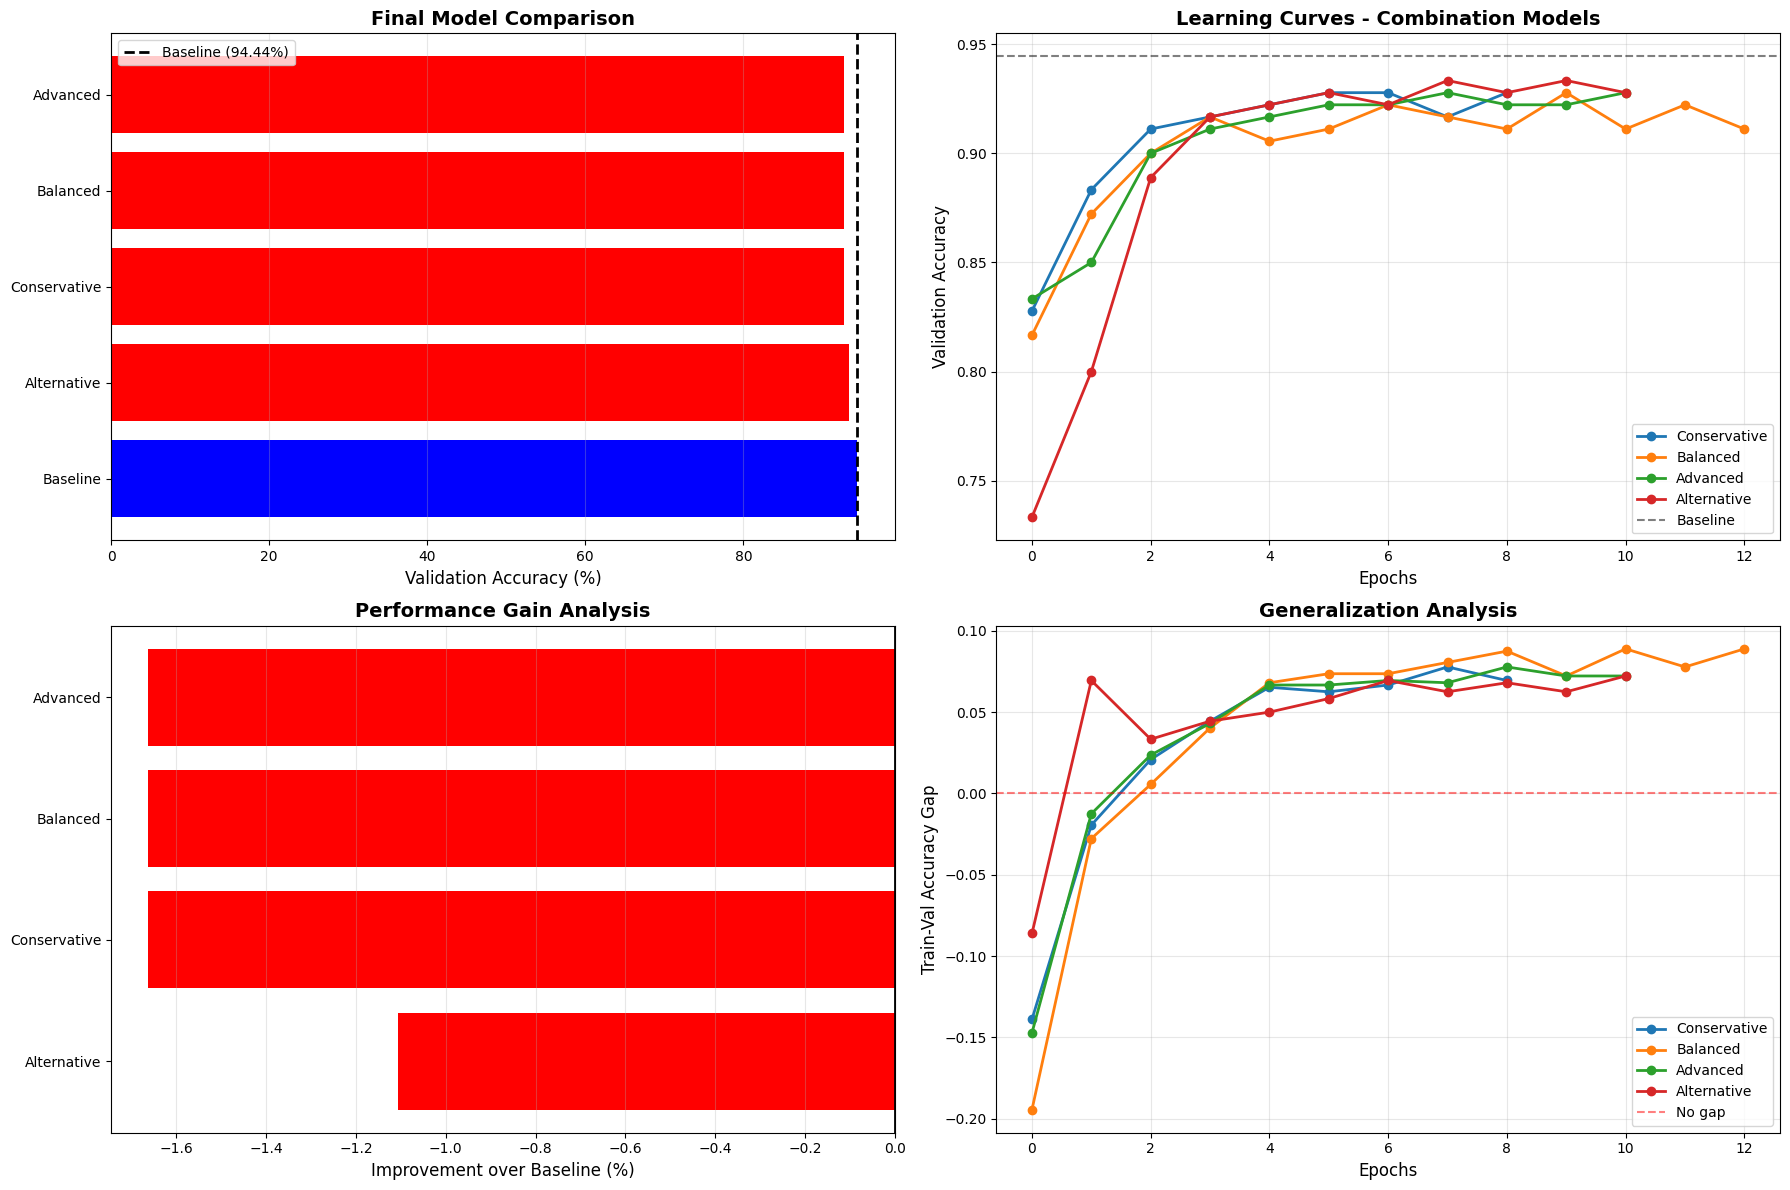


Plots saved to 'results/final_combination_analysis.png'

BEST MODEL:
  Baseline: 94.44%
  Improvement: +0.00%


In [31]:
# ============================================================================
# FINAL COMPARISON AND ANALYSIS
# ============================================================================

print("\n" + "="*70)
print("FINAL RESULTS - ALL EXPERIMENTS")
print("="*70)

# Gather all results including baseline
all_final_results = {
    'Baseline': {'best_val_acc': 0.9444, 'name': 'Baseline_Simple_ViT'},
    **{k: {'best_val_acc': v['best_val_acc'], 'name': v['config']['name']} 
       for k, v in combination_results.items()}
}

# Create comparison table
final_data = []
for key, res in all_final_results.items():
    improvement = (res['best_val_acc'] - 0.9444) * 100
    final_data.append({
        'Experiment': key.capitalize(),
        'Val Acc (%)': res['best_val_acc'] * 100,
        'Improvement vs Baseline (%)': improvement,
        'Status': '✓ BETTER' if improvement > 0 else ('= EQUAL' if improvement == 0 else '✗ WORSE')
    })

df_final = pd.DataFrame(final_data).sort_values('Val Acc (%)', ascending=False)

print("\n" + df_final.to_string(index=False))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot 1: Accuracy comparison
colors = ['blue' if x == 'Baseline' else ('green' if improvement > 0 else 'red') 
          for x, improvement in zip(df_final['Experiment'], df_final['Improvement vs Baseline (%)'])]
axes[0, 0].barh(df_final['Experiment'], df_final['Val Acc (%)'], color=colors)
axes[0, 0].axvline(x=94.44, color='black', linestyle='--', linewidth=2, label='Baseline (94.44%)')
axes[0, 0].set_xlabel('Validation Accuracy (%)', fontsize=12)
axes[0, 0].set_title('Final Model Comparison', fontweight='bold', fontsize=14)
axes[0, 0].legend()
axes[0, 0].grid(axis='x', alpha=0.3)

# Plot 2: Training curves
for key, res in combination_results.items():
    if res['val_accs']:
        axes[0, 1].plot(res['val_accs'], label=key.capitalize(), linewidth=2, marker='o')
axes[0, 1].axhline(y=0.9444, color='black', linestyle='--', alpha=0.5, label='Baseline')
axes[0, 1].set_xlabel('Epochs', fontsize=12)
axes[0, 1].set_ylabel('Validation Accuracy', fontsize=12)
axes[0, 1].set_title('Learning Curves - Combination Models', fontweight='bold', fontsize=14)
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Plot 3: Improvement over baseline
improvements = df_final[df_final['Experiment'] != 'Baseline']
imp_colors = ['green' if x > 0 else 'red' for x in improvements['Improvement vs Baseline (%)']]
axes[1, 0].barh(improvements['Experiment'], improvements['Improvement vs Baseline (%)'], color=imp_colors)
axes[1, 0].axvline(x=0, color='black', linestyle='-', linewidth=2)
axes[1, 0].set_xlabel('Improvement over Baseline (%)', fontsize=12)
axes[1, 0].set_title('Performance Gain Analysis', fontweight='bold', fontsize=14)
axes[1, 0].grid(axis='x', alpha=0.3)

# Plot 4: Overfitting analysis
for key, res in combination_results.items():
    if res['train_accs'] and res['val_accs']:
        gap = np.array(res['train_accs']) - np.array(res['val_accs'])
        axes[1, 1].plot(gap, label=key.capitalize(), linewidth=2, marker='o')
axes[1, 1].axhline(y=0, color='red', linestyle='--', alpha=0.5, label='No gap')
axes[1, 1].set_xlabel('Epochs', fontsize=12)
axes[1, 1].set_ylabel('Train-Val Accuracy Gap', fontsize=12)
axes[1, 1].set_title('Generalization Analysis', fontweight='bold', fontsize=14)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/final_combination_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlots saved to 'results/final_combination_analysis.png'")

# Save final results
with open('results/final_combinations.json', 'w') as f:
    json.dump({k: {**v, 'config': str(v['config'])} for k, v in combination_results.items()}, f, indent=2)

print("\n" + "="*70)
print("BEST MODEL:")
best = df_final.iloc[0]
print(f"  {best['Experiment']}: {best['Val Acc (%)']:.2f}%")
print(f"  Improvement: {best['Improvement vs Baseline (%)']:+.2f}%")
print("="*70)